### Loading model


In [ ]:
#%pip install cobra

In [1]:
import jupyter_utils as ju

In [2]:
import importlib
importlib.reload(ju)

<module 'jupyter_utils' from 'c:\\Users\\adam-1y9pxi6q95ggpmx\\Documents\\PhD\\SoF1-GEM\\Scripts\\jupyter_utils.py'>

In [23]:
base_dir = Path.home() / "Documents" / "PhD" / "SOF1-GEM"
#base_dir = Path.home() / "Documents" / "PhD" / "SOF1-GEM" 
model = ju.load_model(base_dir,"Models", "250808_iABA974.sbml")
#model = ju.load_model(base_dir,"Models", "250924_iABA974_BLG.sbml")



In [111]:
# set reactions bounds for a specific reaction 
reaction = model.reactions.get_by_id('EX_h2_e')
reaction.bounds = -19.42, 0.0

reaction = model.reactions.get_by_id('EX_o2_e')
reaction.bounds = -1000.0, 0.0

reaction = model.reactions.get_by_id('EX_co2_e')
reaction.bounds = -1000.0, 0.0



In [36]:
reaction = model.reactions.get_by_id('Growth')
reaction.bounds = -0.0, 0.0
reaction = model.reactions.get_by_id('EX_h2_e')
reaction.bounds = -20.0, 0.0

In [37]:
model.objective = "BLG_x1_production"
model.optimize()
model.summary()

Metabolite,Reaction,Flux,C-Number,C-Flux
co2_e,EX_co2_e,2.553,1,100.00%
h2_e,EX_h2_e,20,0,0.00%
nh4_e,EX_nh4_e,0.6713,0,0.00%
o2_e,EX_o2_e,7.474,0,0.00%
so4_e,EX_so4_e,0.01321,0,0.00%
Metabolite,Reaction,Flux,C-Number,C-Flux
BLG_x1_e,EX_BLG_x1_e,-0.515,0,0.00%
h2o_e,EX_h2o_e,-18.86,0,0.00%


# Manual Curation

## Reactions & metabolites 

#### GPR rule from reaction

In [61]:
rxn = model.reactions.get_by_id("ACLS")
print(rxn.gene_reaction_rule)

AAFOLC_07030 or AAFOLC_07145 or AAFOLC_08330 or AAFOLC_08635 or AAFOLC_18280 or AAFOLC_19745 or (AAFOLC_08330 and AAFOLC_08335)


#### Metabolite reaction summary

In [50]:
metabolite_to_check = model.metabolites.get_by_id('h_c')
summary = metabolite_to_check.summary()

In [51]:
summary

Percent,Flux,Reaction,Definition
0.14%,0.1981,AACT,accoa_c + akg_c + h2o_c + 2.0 h_c <=> coa_c + hcit_c
0.14%,0.1981,AASAD3,L2aadp6sa_c + h2o_c + nad_c --> L2aadp_c + 2.0 h_c + nadh_c
0.23%,0.3324,ACOAD7,nad_c + pmtcoa_c <=> h_c + hdd2coa_c + nadh_c
0.02%,0.03081,ADSS,asp__L_c + gtp_c + imp_c --> dcamp_c + gdp_c + 2.0 h_c + pi_c
0.00%,0.006603,AHSERL2,achms_c + h2s_c --> ac_c + h_c + hcys__L_c
0.01%,0.01541,ANS2,chor_c + nh4_c --> anth_c + h2o_c + h_c + pyr_c
0.74%,1.067,APAT_1,atp_c + h_c + ppa_c <=> ppad_c + ppi_c
0.01%,0.01981,ARGSS,asp__L_c + atp_c + citr__L_c --> amp_c + argsuc_c + h_c + ppi_c
0.00%,0.004402,ASNS1,asp__L_c + atp_c + gln__L_c + h2o_c --> amp_c + asn__L_c + glu__L_c + h_c + ppi_c
14.69%,21.2,ATPM,atp_c + h2o_c --> adp_c + h_c + pi_c


##### Create a dataframe of this metabolite summary

create a file pathway for this fct

In [12]:
# Extracting the data for file naming
import time
year = time.strftime("%Y")[2:4]
timestr = time.strftime("%m%d")
base_dir = Path.home() / "Documents" / "PhD" / "10-19 Research" / "11 Data" / "11.03_Fluxes_values" / "11.03.02_substrate_summary"
filename = f"{year}{timestr}_{metabolite_to_check.id}_summary.xlsx"
file_path = base_dir / filename
ju.metabolite_summary_df(model,summary,file_path)

### Search metabolite

In [25]:
search_word = 'BLG'
ju.search_metabolite_info(model,search_word)
#search_word = 'caro_c'
#ju.search_metabolite_info(model1,search_word)


🧪 Metabolite: BLG_x1_c
 - Name       : BLG_x1
 - Formula    : None
 - Charge     : 0
 - Compartment: c
 - Annotations: {}
 - Related Reactions: BLG_x1_production, BLG_x1t
 - Associated Genes : 

🧪 Metabolite: BLG_x1_e
 - Name       : BLG_x1
 - Formula    : None
 - Charge     : 0
 - Compartment: e
 - Annotations: {}
 - Related Reactions: EX_BLG_x1_e, BLG_x1t
 - Associated Genes : 


### Search reaction

In [41]:
search_word = 'BLG_x1t'
ju.search_reaction_info(model,search_word)


🔎 Reaction ID: BLG_x1t
 - Name        : 
 - Equation    : BLG_x1_c --> BLG_x1_e
 - Lower Bound : 0.0
 - Upper Bound : 1000.0
 - Annotations : {}
 - Genes       : []


Show reaction details

In [40]:
ju.print_reaction_details(model, 'EX_BLG_x1_e')


Reaction ID   : EX_BLG_x1_e
Name          : BLG_x1 exchange
Equation      : BLG_x1_e <=> 
Lower Bound   : -1000.0
Upper Bound   : 1000.0

Metabolites and Stoichiometry:
 - BLG_x1_e       :   -1.0  Name: BLG_x1                                             Charge:   0  Formula: None

Sum of Charge Balance: 0.0

Associated Genes:
 - None


### Check reaction flux

In [38]:
objective_rxn ='Growth'
flux = ju.check_reaction_flux(objective_rxn,model, 'NADTRHD')

There is no flux through the reaction 'NADTRHD'.


Check reaction fluxes from a specific metabolite

In [37]:
met = 'h2_c'
solution = model.optimize()
active_rxns = ju.get_active_reactions_for_metabolite(model, solution, met)

# Optionally print
for r in active_rxns:
    print(f"{r[1]}: {r[0]}")
    print(f"  Equation: {r[2]}")
    print(f"  Flux: {r[3]:.3f} mmol/gDW/hr\n")

H2tpp: Hydrogen transport diffusion (periplasm)
  Equation: h2_p <=> h2_c
  Flux: 19.400 mmol/gDW/hr

FERHYD: ferredoxin hydrogenase
  Equation: 2.0 fdxrd_c + 2.0 h_c <=> 2.0 fdxo_2_2_c + h2_c
  Flux: -1.114 mmol/gDW/hr

NAD_H2: NAD-linked hydrogenase
  Equation: h_c + nadh_c <=> h2_c + nad_c
  Flux: -18.286 mmol/gDW/hr



### Change reaction bounds

In [8]:
model.reactions.get_by_id('NAD_H2').bounds = -0.0, 0.0

### Search in reaction annotation

In [ ]:
for reaction in model.reactions:
    print(reaction.annotation)

{'sbo': 'SBO:0000243'}
{'sbo': 'SBO:0000243'}
{'sbo': 'SBO:0000243'}
{'sbo': 'SBO:0000243', 'kegg.genes': 'Xaut_1442'}
{'sbo': 'SBO:0000243'}
{'sbo': 'SBO:0000243'}
{'sbo': 'SBO:0000243'}
{'sbo': 'SBO:0000243', 'kegg.genes': 'Xaut_4429'}
{'sbo': 'SBO:0000243', 'kegg.genes': 'Xaut_0054'}
{'sbo': 'SBO:0000243', 'kegg.genes': 'EZH22_20190'}
{'sbo': 'SBO:0000243', 'kegg.genes': 'Xaut_3107'}
{'sbo': 'SBO:0000243'}
{'sbo': 'SBO:0000243', 'kegg.genes': 'Xaut_1120'}
{'sbo': 'SBO:0000243', 'kegg.genes': 'EZH22_09440'}
{'sbo': 'SBO:0000243', 'kegg.genes': 'Xaut_1259'}
{'sbo': 'SBO:0000243', 'kegg.genes': 'EZH22_08125'}
{'sbo': 'SBO:0000243', 'kegg.genes': 'Xaut_3115'}
{'sbo': 'SBO:0000243'}
{'sbo': 'SBO:0000243'}
{'sbo': 'SBO:0000243', 'kegg.genes': 'Xaut_3108'}
{'sbo': 'SBO:0000243', 'kegg.genes': 'Xaut_1122'}
{'sbo': 'SBO:0000243', 'kegg.genes': 'Xaut_2636'}
{'sbo': 'SBO:0000243', 'kegg.genes': 'Xaut_2635'}
{'sbo': 'SBO:0000243'}
{'sbo': 'SBO:0000243', 'kegg.genes': 'Xaut_2634'}
{'sbo': 'SBO:0

### Check reaction by EC-number

In [86]:
ec_code_wanted = '1.18.6.1'
for reaction in model.reactions:
    ec_code_value = reaction.annotation.get('kegg-id')
    if ec_code_value and ec_code_wanted in ec_code_value:
        print(reaction.id)

### Add Metabolite

In [ ]:
new_metabolite = Metabolite(
    id='lnlncg_c',     # Metabolite ID
    name='Gamma-linolenic acid',     # Metabolite Name
    formula='C18H29O2',         # Chemical Formula
    compartment='c'            # Compartment (e.g., cytoplasm)
)


new_metabolite.annotation = {'kegg.compound':'C03035'}
new_metabolite.charge = -1 

model.add_metabolites([new_metabolite])

print(new_metabolite.formula)

### Add Reaction

In [ ]:
ID = 'CYTHYD'
if ID not in model.reactions:
    reaction = Reaction(ID)
    reaction.name = 'cytochrome-c3 hydrogenase'
    reaction.lower_bound =  -1000.0
    reaction.upper_bound = 1000.0
    reaction.annotation = {'kegg.reaction':' R04015' , 'ec-code': '1.12.2.1'}
    # HAA.annotation = {'biocyc':'CPD-9436', 'chebi':'35194', 'chemspider':'6309', 'inchi':' InChI=1S/C5H8/c1-4-5(2)3/h4H,1-2H2,3H3', 'kegg.compound':'C16521', 'pubchem':'6557'}    
    h2 = model.metabolites.get_by_id('h2_c')
    h = model.metabolites.get_by_id('h_c')  
    n2 = model.metabolites.get_by_id('n2_c')
    pi = model.metabolites.get_by_id('pi_c')
    fdxrd = model.metabolites.get_by_id('ficytc_c')
    fdxo_2_2 = model.metabolites.get_by_id('focytc_c')
    nh3 = model.metabolites.get_by_id('nh3_c')       
    reaction.add_metabolites({fdxrd:-2.,h2:-1.,fdxo_2_2:2.,h:2.})
    
    model.add_reactions([reaction])
    

    print(model.reactions.get_by_id(ID).id)
    print(model.reactions.get_by_id(ID).reaction)

### Add Sink Reaction

In [11]:
model.add_boundary(model.metabolites.get_by_id('hdca_c'), type='sink',lb=0.0, ub=1000)

Reaction identifier,SK_hdca_c
Name,palmitate sink
Memory address,0x2024dfa4710
Stoichiometry,hdca_c --> palmitate -->
GPR,
Lower bound,0.0
Upper bound,1000


### Add annotation to reaction

In [ ]:
reaction = copy_of_model.reactions.get_by_id('LINO_6_DESA')
reaction.name = 'Δ6-Desaturation of Linoleoyl-CoA'
reaction.annotation["kegg.reaction"] = "R00878"
reaction.annotation["ec-code"] = "5.3.1.5"
#reaction.annotation["metanetx.reaction"] = "MNXR95442"

print(reaction.annotation)

### Remove reaction

In [ ]:
reaction_id = "ACACDC"
model.remove_reactions([reaction_id])
# Verify the removal
if reaction_id not in model.reactions:
    print(f"Reaction {reaction_id} has been successfully removed.")
else:
    print(f"Failed to remove reaction {reaction_id}.")

## Genes

### Search gene

In [47]:
gene_id ='AAFOLC_00185'
ju.print_gene_reaction_info(model, gene_id)

Gene 'AAFOLC_00185' not found in the model.


In [10]:
for gene in model.genes:
    print(gene.annotation)

{'sbo': 'SBO:0000243', 'asap': 'ABE-0008389', 'ecogene': 'EG10408', 'ncbigene': '947022', 'ncbigi': '16130476', 'refseq_locus_tag': 'b2551', 'refseq_name': 'glyA', 'refseq_synonym': ['ECK2548', 'JW2535'], 'uniprot': 'P0A825'}
{'sbo': 'SBO:0000243', 'asap': 'ABE-0002954', 'ecogene': 'EG13690', 'ncbigene': '944955', 'ncbigi': '16128838', 'refseq_locus_tag': 'b0870', 'refseq_name': 'ltaE', 'refseq_synonym': ['ltaA', 'JW0854', 'ECK0861', 'ybjU'], 'uniprot': 'P75823'}
{'sbo': 'SBO:0000243', 'asap': 'ABE-0011010', 'ecogene': 'EG10188', 'ncbigene': '947880', 'ncbigi': '16131246', 'refseq_locus_tag': 'b3368', 'refseq_name': 'cysG', 'refseq_synonym': ['JW3331', 'ECK3356'], 'uniprot': 'P0AEA8'}
{'sbo': 'SBO:0000243', 'asap': 'ABE-0008034', 'ecogene': 'EG12189', 'ncbigene': '946908', 'ncbigi': '16130361', 'refseq_locus_tag': 'b2436', 'refseq_name': 'hemF', 'refseq_synonym': ['JW2429', 'ECK2431', 'sec', 'popB'], 'uniprot': 'P36553'}
{'sbo': 'SBO:0000243', 'asap': 'ABE-0000027', 'ecogene': 'EG11556

### Add gene

In [5]:
if gene_id not in model.genes:
    new_gene = Gene(id=gene_id)
    model.genes.append(new_gene)
else:
    new_gene = model.genes.get_by_id(gene_id)

Add gene to specific reaction

In [ ]:
reaction = model.reactions.get_by_id('CYTHYD')
#for single gene
#reaction.gene_reaction_rule = gene_id

genes_list = ['AAFOLC_02505','AAFOLC_02510']

# Assign genes using "or" (if any of these genes can catalyze the reaction)
#reaction.gene_reaction_rule = ' or '.join(genes_list)

# If all genes are required together, use " and " instead
reaction.gene_reaction_rule = ' and '.join(genes_list)

# Check assigned genes
print(reaction.genes)
reaction.genes

### Add annotation to gene

In [ ]:
gene = model.genes.get_by_id("AAFOLC_01125")
# Add annotations
gene.annotation["uniprot"] = "Q89CN4"

# Verify the annotation
print(gene.annotation)

## Run pFBA 

In [62]:
from cobra.flux_analysis import pfba
model.objective = "Growth"
solution = model.optimize()
# Perform parsimonious FBA (optional, to minimize overall flux)
pfba_solution = pfba(model)
pfba_fluxes = pfba_solution.fluxes
print(pfba_solution.fluxes)

# Print the flux through the sink reaction for 3PG
print(f"Flux through the objective reaction: {fba_solution.fluxes['Growth']}")

EX_25dkglcn_e       0.000000
EX_2ameph_e         0.000000
EX_2m35mdntha_e     0.000000
EX_2pglyc_e         0.000000
EX_34dhbz_e         0.000000
                      ...   
FACOAE1836Z9Z12Z    0.000016
NIT                 0.000000
FERHYD             -0.457068
CYTHYD              0.000000
Growth              0.044474
Name: fluxes, Length: 2389, dtype: float64
Flux through the objective reaction: 0.04447377605182415


find essential reaction

In [63]:
essential = pfba_fluxes[(pfba_fluxes != 0)]
essential

EX_ca2_e           -0.000220
EX_cl_e            -0.000220
EX_co2_e           -2.124340
EX_cobalt2_e       -0.000001
EX_cu2_e           -0.000300
                      ...   
OLEO_12_DESA        0.000279
LINO_6_DESA         0.000016
FACOAE1836Z9Z12Z    0.000016
FERHYD             -0.457068
Growth              0.044474
Name: fluxes, Length: 474, dtype: float64

#### Show the fluxes with a detailed description of the reaction

In [ ]:
significant_reactions = [
    [
        model.reactions[RctIdx].name, 
        solution.to_frame().iloc[RctIdx].name, 
        model.reactions[RctIdx].reaction, 
        round(solution.fluxes[RctIdx], 2)
    ]
    for RctIdx in np.where(np.abs(solution.fluxes) > 3)[0]
]

# Create a DataFrame for better visualization
df = pd.DataFrame(significant_reactions, columns=["Reaction Name", "Reaction ID", "Reaction Equation", "Flux"])

# Print the DataFrame
df

C:\Users\adam-1y9pxi6q95ggpmx\AppData\Local\Temp\ipykernel_1316\1631945521.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  round(solution.fluxes[RctIdx], 2)


,Reaction Name,Reaction ID,Reaction Equation,Flux
0,EX_h2_e,EX_h2_e,h2_e <--,-18.78
1,EX_h2o_e,EX_h2o_e,h2o_e <=>,17.54
2,EX_o2_e,EX_o2_e,o2_e <--,-6.92
3,ATP synthase (four protons for one ATP) (perip...,ATPS4rpp,adp_c + 4.0 h_p + pi_c <=> atp_c + h2o_c + 3.0...,20.78
4,Cytochrome oxidase bd (ubiquinol-8: 2 protons)...,CYTBDpp,2.0 h_c + 0.5 o2_c + q8h2_c --> h2o_c + 2.0 h_...,13.85
5,Glyceraldehyde-3-phosphate dehydrogenase,GAPD,g3p_c + nad_c + pi_c <=> 13dpg_c + h_c + nadh_c,-3.72
6,Bidirectional [NiFe] Hydrogenase,H2ASE_syn,h_c + nadph_c <=> h2_c + nadp_c,-18.78
7,H2O transport via diffusion,H2Ot,h2o_e <=> h2o_c,-17.73
8,Hydrogen transport via diffusion (extracellula...,H2tex,h2_e <=> h2_p,18.78
9,Hydrogen transport diffusion (periplasm),H2tpp,h2_p <=> h2_c,18.78


## Mass and charge balance

### Read excel files

In [55]:
# Base directory path
base_dir = Path.home() / "Documents" / "PhD" / "10-19 Research" / "11 Data" / "11.09_Models"

# Correct path construction using '/' operator
file_path = base_dir / "Manual_curation" / "Modified reactions.xlsx"
file_path_1 = base_dir / "Manual_curation" / "Modified formula.xlsx"
file_path_2 = base_dir / "Manual_curation" / "Manually modified reactions.xlsx"

# Read Excel files into DataFrames
excel_data_charge = pd.read_excel(file_path)
excel_data_formula = pd.read_excel(file_path_1)
excel_data_Manualcuration = pd.read_excel(file_path_2)

### Check number of unbalanced reactions

In [ ]:
ju.check_model_mass_balance(model)

5
Reaction ID: DHNAOT, Charge Balance: {'charge': 2.0}
Reaction ID: HDECH, Charge Balance: {'charge': 2.0}
Reaction ID: MECDPDH4E, Charge Balance: {'charge': -1.0}
Reaction ID: P9DH, Charge Balance: {'charge': 4.0}
Reaction ID: THZSN_1, Charge Balance: {'H': -1.0}


reaction details

In [50]:
ju.print_reaction_details(model, 'HDECH')


Reaction ID   : HDECH
Name          : 
Equation      : 1hdecg3p_c + h2o_c <=> glyc3p_c + 3.0 h_c + hdcea_c
Lower Bound   : -1000.0
Upper Bound   : 1000.0

Metabolites and Stoichiometry:
 - 1hdecg3p_c     :   -1.0  Name: 1-hexadecanoyl-sn-glycerol 3-phosphate             Charge:  -2  Formula: C19H37O7P
 - h2o_c          :   -1.0  Name: H2O H2O                                            Charge:   0  Formula: H2O
 - glyc3p_c       :    1.0  Name: Glycerol 3-phosphate                               Charge:  -2  Formula: C3H7O6P
 - h_c            :    3.0  Name: H+                                                 Charge:   1  Formula: H
 - hdcea_c        :    1.0  Name: Hexadecenoate (n-C16:1)                            Charge:  -1  Formula: C16H29O2

Sum of Charge Balance: 2.0

Associated Genes:
 - None


### add metabolite to balance reaction

In [49]:
reaction = model.reactions.get_by_id('CYTHYD')
metabolite_to_add = 'h_c'
reaction.add_metabolites({metabolite_to_add: -4.0})
reaction

Reaction identifier,CYTHYD
Name,cytochrome-c3 hydrogenase
Memory address,0x1fbaa5a93d0
Stoichiometry,2.0 ficytc_c + h2_c <=> 2.0 focytc_c + 2.0 h_p 2.0 Ferricytochrome c C42H52FeN8O6S2 + Hydrogen <=> 2.0 Ferrocytochrome c C42H53FeN8O6S2 + 2.0 H+
GPR,AAFOLC_02505 and AAFOLC_02510
Lower bound,-1000.0
Upper bound,1000.0


Add modification to Excel file

In [ ]:
modification =f'{metabolite_to_add} was added'
# Create a new row with the modification information
new_row = {'reaction ': reaction_id_to_check, 'modification': modification}
# Concatenate the new row to the DataFrame
excel_data_Manualcuration = pd.concat([excel_data_Manualcuration, pd.DataFrame([new_row])], ignore_index=True)

### Remove metabolite

In [46]:
reaction = copy_of_model.reactions.get_by_id('Growth')
metabolite_to_add = 'pe161_p'
reaction.subtract_metabolites({metabolite_to_add: -0.02106})
print(reaction.reaction)

0.000223 10fthf_c + 0.000223 2dmmql8_c + 0.000223 5mthf_c + 0.000279 accoa_c + 0.8168723181883314 ala__L_c + 0.000223 amet_c + 0.03001579312991268 arab__L_c + 0.2557979323259868 arg__L_c + 0.2529593526847482 asn__L_c + 0.2529593526847482 asp__L_c + 37.86 atp_c + 0.004952 ca2_c + 0.000223 chor_c + 0.004952 cl_c + 0.002944 clpn160_p + 0.00229 clpn161_p + 0.00118 clpn181_p + 0.000168 coa_c + 2.4e-05 cobalt2_c + 0.010737250405651103 ctp_c + 0.006744 cu2_c + 0.037472225353906465 cys__L_c + 0.014832979735072188 datp_c + 0.0154992827580827 dctp_c + 0.02400546922059191 dgtp_c + 0.013367475433835764 dttp_c + 0.000223 fad_c + 0.006388 fe2_c + 0.007428 fe3_c + 0.6445556055168562 fru_c + 0.005772 gal_c + 0.11736684160157697 glc__D_c + 0.2753206379465721 gln__L_c + 0.275320637946572 glu__L_c + 0.6379660350235106 gly_c + 0.01659016153669234 gtp_c + 37.86 h2o_c + 0.000223 hemeO_c + 0.049934570136758984 hexadecacid_c + 0.007033277906537638 hexedecacid_c + 0.09352200626083922 his__L_c + 0.2450643067545

Add modification to Excel file

In [217]:
modification =f'{metabolite_to_add} was removed'
# Create a new row with the modification information
new_row = {'reaction ': reaction_id_to_check, 'modification': modification}
# Concatenate the new row to the DataFrame
excel_data_Manualcuration = pd.concat([excel_data_Manualcuration, pd.DataFrame([new_row])], ignore_index=True)

### Change charge of metabolite

In [80]:
metabolite_id = 'fdxrd_c'
if metabolite_id in model.metabolites:
    metabolite = model.metabolites.get_by_id(metabolite_id)
    initial_charge = metabolite.charge  # Store the initial charge for reference
    metabolite.charge = -2
    metabolite.compartment = 'c'
    
    print(list(metabolite.reactions))  
    # Print information about the modified metabolite
    print(f"Modified metabolite: {metabolite.id}")
    print(f"Updated charge: {metabolite.charge}")
    print(f"compartment: {metabolite.compartment}")
else:
    print("Metabolite not found in the model.")

[<Reaction MECDPDH3_syn at 0x1c8cadaa450>, <Reaction MECDPDH4E at 0x1c8cadab890>, <Reaction COCO2 at 0x1c8ca75c0d0>, <Reaction FNOR at 0x1c8ca58bb10>, <Reaction GLUSfx at 0x1c8caa89f10>, <Reaction NOR_syn_1 at 0x1c8caef1110>, <Reaction NIT at 0x1c8cb4bf910>, <Reaction HMEDS at 0x1c8cac16350>, <Reaction THZSN_1 at 0x1c8cb2fb350>]
Modified metabolite: fdxrd_c
Updated charge: -2
compartment: c


#### Add to excel file

In [155]:
# Create a dictionary containing information about the modified reaction
new_row = {'Reaction': reaction_id_to_check, 'metabolite changed': metabolite_id, 'initial charge': initial_charge, 'New charge': metabolite.charge}
excel_data_charge = pd.concat([excel_data_charge, pd.DataFrame([new_row])], ignore_index=True)
excel_data_charge

,Reaction,metabolite changed,initial charge,New charge
0,2AGPG161tipp,2agpg161_c,0,-1
1,3HACPH,r3hbACP_c,0,-1
2,3HAD140,tmrs2eACP_c,0,-1
3,4HOXPACt2pp_1,4hoxpac_p,0,-1
4,4OXPTNtpp,4oxptn_p,0,-1
5,4OXPTNtex,4oxptn_e,0,-1
6,4hoxpactex,4hoxpac_e,0,-1
7,6ATHAtexi,6atha_e,0,-1
8,AADa,aad_c,0,-1
9,ACLS_b,hethmpp_c,-1,-2


### Change formula of metabolite

In [97]:
metabolite_id = 'fdxrd_c'
metabolite = model.metabolites.get_by_id(metabolite_id)
initial_formula = metabolite.formula
metabolite.formula = 'Fe8S8'

#### Add to excel file

In [186]:
new_row_1 = {
    'Reaction': reaction_id_to_check,        # ID of the reaction associated with the metabolite change
    'metabolite changed': metabolite_id,     # ID of the metabolite that was changed
    'initial formula': initial_formula,      # Initial formula of the metabolite
    'New formula': metabolite.formula        # New formula of the metabolite after modification
}
excel_data_formula = pd.concat([excel_data_formula, pd.DataFrame([new_row_1])], ignore_index=False)

excel_data_formula = excel_data_formula.reset_index(drop=True)


In [ ]:
excel_data_formula

## Save updated files

#### Save Excel

In [264]:
# Save the updated DataFrame to the Excel file
excel_data_charge.to_excel(file_path, index=False)
excel_data_formula.to_excel(file_path_1, index=False)
excel_data_Manualcuration.to_excel(file_path_2, index=False)

#### Save model in SBML 

In [33]:
# Base directory path
base_dir = Path.home() / "Documents" / "PhD" / "SoF1-GEM" / "Models"
# Correct path construction using '/' operator
file_path = base_dir / "251226_iABA974_updated_ETC.sbml"
sbml_filename = file_path

#json_filename = file_path

#cobra.io.json.save_json_model(model,json_filename)
cobra.io.write_sbml_model(model, sbml_filename)

## Exchange reaction

In [47]:
copy_of_model = model.copy()

In [ ]:
# set exchange reactions bounds to zero if they significally affect the growth
ex_list = []

not_to_change_list = ['EX_ca2_e','EX_cl_e','EX_cobalt2_e','EX_cu2_e','EX_h2o_e','EX_h2_e','EX_fe_e','EX_fe2_e','EX_fe3_e'
                      ,'EX_k_e','EX_mg2_e','EX_mn2_e','EX_zn2_e','EX_o2_e','EX_so4_e','EX_pi_e','EX_nh4_e','EX_mobd_e','EX_ni2_e']

for element in copy_of_model.exchanges:
    reaction = copy_of_model.reactions.get_by_id(element.id)
    
    # Iterate over metabolites associated with the reaction
    for metabolite, coefficient in reaction.metabolites.items():
        if element.id not in not_to_change_list:
            # Set reaction bounds to zero
            reaction.bounds = 0.0, 0.0
            
            # Optimize the model
            solution = copy_of_model.slim_optimize()
            
            # Check if the solution is not zero
            if solution != 0.0:
                ex_list.append(reaction.id)
                
            # Print reaction information
            print(reaction.name)
            print(solution)

In [90]:
# change bounds of the exchange reactions
for element in reaction:
    reaction = copy_of_model.reactions.get_by_id(element)
    for metabolite, coefficient in reaction.metabolites.items():
        print(reaction.name)
        print(metabolite.name)
        print(metabolite.formula)
        reaction.bounds = -1000.0 , 1000.0

In [ ]:
# set reactions bounds for a specific reaction 
reaction = copy_of_model.reactions.get_by_id('EX_co2_e')
reaction.bounds = -1000.0, 1000.0

## Biomass Equation Curation

Updating the coefficient and adding metabolites from the Solar Food Biomass Equation

In [2]:
# Read Excel files into DataFrames
base_dir = Path.home() / "Documents" / "PhD" / "10-19 Research" / "11 Data" 
file_path = base_dir / "11.09_Models" / "Manual_curation" / "Biomass_equation" / "Biomass_equation.xlsx"
df_biomass = pd.read_excel(file_path)
df_biomass

,Biomass_equation,Unnamed: 1,molar mass g/mol,measured mmol/g,Unmeasured mmol/g,unmeasured g/g,measured g/g,GAM,normalized g/g,normalized_mmol/g
0,10fthf_c,10-Formyltetrahydrofolate,471.43007,NaN,-0.000223,-0.000105,NaN,NaN,0.000000,-0.000223
1,pydx5p_c,Pyridoxal 5'-phosphate,245.12862,NaN,-0.000223,-0.000055,NaN,NaN,0.000000,-0.000223
2,murein3px4p_p,"Two disacharide linked murein units, tripeptid...",1750.69809,NaN,-0.000605,-0.001059,NaN,NaN,0.000000,-0.000605
3,thr__L_c,L-Threonine,119.12063,-0.381786,NaN,0.000000,-0.045479,NaN,-0.039411,-0.330852
4,adocbl_c,Adenosylcobalamin,1579.60636,NaN,-0.000223,-0.000352,NaN,NaN,0.000000,-0.000223
...,...,...,...,...,...,...,...,...,...,...
124,tmndnc_c,"Timnodonic acid C20:5, n-3",302.50000,-0.000044,NaN,0.000000,-0.000013,NaN,-0.000011,-0.000038
125,doco13ac_c,13Z)-13-docosenoic acid,338.60000,-0.000077,NaN,0.000000,-0.000026,NaN,-0.000023,-0.000067
126,ttc_c,Tetracosanoate n C240 C24H47O2,368.60000,-0.000035,NaN,0.000000,-0.000013,NaN,-0.000011,-0.000030
127,lnlc_c,Linoleic acid (all cis C18:2) n-6,280.40000,-0.000222,NaN,0.000000,-0.000062,NaN,-0.000054,-0.000193


Change the coeff from the excel file of the already exisiting metabolite of the growth equation

In [ ]:
updated_count = ju.update_biomass_from_dataframe(model, df_biomass)


Compare the coeff of the excel to the one in the model

In [ ]:
i=0
reaction = copy_of_model.reactions.get_by_id('Growth')
for element in pd_biomass.Biomass_equation:
    for metabolite, coefficient in reaction.metabolites.items():
        if element == metabolite.id:
            print(element)
            normalized_mmol_g = pd_biomass.loc[pd_biomass['Biomass_equation'] == element, 'normalized_mmol/g'].values[0]
            print(normalized_mmol_g)
            print(coefficient)
            i+=1
print(i)

Create a dict to see which metabolite are not in the model biomass equation

In [ ]:
missing_df = ju.find_missing_biomass_metabolites(
    model,
    df_biomass,
    output_path=Path.home() / "Desktop" / "metabolitenotfound_biomass_equation.xlsx"
)

missing_df.head()

Create a dict to see which metabolite are only in the model and not in experimental biomass equation

In [ ]:
df_unlisted = ju.find_unlisted_biomass_metabolites(
    model,
    df_biomass,
    output_path=Path.home() / "Desktop" / "metabolitenotfound_biomass.xlsx"
)

df_unlisted.head()

6


,metabolite_id,metabolite_name,coefficient
0,kdo2lipid4_p,KDO(2)-lipid IV(A),-0.019456
1,murein5px4p_p,"Two disacharide linked murein units, pentapept...",-0.013894
2,pe160_c,"Phosphatidylethanolamine (dihexadecanoyl, n-C1...",-0.017868
3,pe161_c,"Phosphatidylethanolamine (dihexadec-9enoyl, n-...",-0.054154
4,pe161_p,"Phosphatidylethanolamine (dihexadec-9enoyl, n-...",-0.021060
5,gal_c,D-Galactose,-0.005772


Compare metabolite from another model biomass equation to the model

In [9]:
df_met_notfound = pd.DataFrame(columns=['metabolite_id','metabolite_name'])

In [ ]:
df_met_notfound = ju.compare_biomass_metabolites_between_models(copy_of_model, copy_of_model1)
df_met_notfound.to_excel(Path.home() / "Desktop" / "missing_biomass_metabolites.xlsx", index=False)
df_met_notfound

Number of metabolites not found: 28


Create a dict with the metabolite that are only in the model biomass equation

In [ ]:
model_BE_metabolite = {}

# Get the 'Growth' reaction
reaction = model1.reactions.get_by_id('BIOMASS_KT2440_WT3')

# Iterate over metabolites in the 'Growth' reaction
for metabolite, coefficient in reaction.metabolites.items():
    # Check if the metabolite ID is not in the 'Biomass_equation' column
    if metabolite.id not in pd_biomass['Biomass_equation'].values:
        # Add the metabolite ID and its coefficient to the dictionary
        model_BE_metabolite[metabolite.id] = coefficient

model_BE_metabolite

#### Add metabolite to biomass composition

In [ ]:
# Convert the dictionary to a DataFrame
df_metabolite_not_found = pd.DataFrame(list(df_met_notfound.items()), columns=['Metabolite', 'Coefficient'])

# Save the DataFrame to an Excel file
output_file = 'C:\\Users\\adam-1y9pxi6q95ggpmx\\Desktop\\metabolite_not_found.xlsx'
df_metabolite_not_found.to_excel(output_file, index=False)

print(f"The data has been saved to {output_file}")

The data has been saved to C:\Users\adam-1y9pxi6q95ggpmx\Desktop\metabolite_not_found.xlsx


#### GAM update

In [60]:
gam1 = {'atp_c': -60.0, 'h2o_c': -60.0}
gam2 = {'adp_c': 60.0, 'pi_c': 60.0, 'h_c': 60.0}
ju.update_GAM_in_biomass(model, gam_dict_1=gam1, gam_dict_2=gam2)

Updated atp_c: -40.0 → -60.0
Updated h2o_c: -40.0 → -60.0
Updated adp_c: 40.0 → 60.0
Updated pi_c: 40.0 → 60.0
Updated h_c: 40.0 → 60.0

Optimal growth rate after GAM update: 0.04233427052170866


0.04233427052170866

# Automatically curate model

add reaction from other model

In [ ]:
reaction_id_to_check = 'ADCYRS'
reaction = copy_of_model1.reactions.get_by_id(reaction_id_to_check)
copy_of_model.add_reactions([reaction])

### Update charges from excel

In [ ]:
# Base directory path
base_dir = Path.home() / "Documents" / "PhD" / "10-19 Research" / "11 Data" / "11.09_Models"

# Correct path construction using '/' operator
file_path = base_dir / "Manual_curation" / "Modified reactions.xlsx"

ju.update_metabolite_charges_from_excel(copy_of_model, file_path)


In [ ]:
ju.check_model_mass_balance(model)

### Create a list of reaction to update with the related model

In [ ]:
import requests
reaction_model_mapping = ju.get_bigg_models_for_imbalanced_reactions(model)


### Update charge from BIGG API

In [ ]:
updated = ju.update_metabolite_charges_from_bigg(model, reaction_model_mapping)


### Update charge and formula from a curated model

In [ ]:
model1 = ju.load_model("Manual_curation", "updated_growth_gapfilled_autotrophic_1.sbml")

In [ ]:
updated_model = ju.update_metabolite_info(model_non_curated, model_curated)


Metabolite 'etoh_e' not found in the curated model.


### Add reactions from a curated model

In [ ]:
updated_model = ju.add_missing_reactions(model_non_curated, model_curated)
print(f"Updated model contains {len(updated_model.reactions)} reactions.")

### Add metabolites from a curated model

In [ ]:
updated_model = ju.dd_missing_metabolites(model_non_curated, model_curated)
print(f"Updated model contains {len(updated_model.metabolites)} metabolites.")

### Update metabolite with coa substring

In [ ]:
substring_to_check = 'coa'
for metabolite in copy_of_model.metabolites:
    if substring_to_check in metabolite.id:
        if metabolite.charge == 0:
            metabolite.charge = -4
            # Print information about the modified metabolite
            print(f"Modified metabolite: {metabolite.id}")
            print(f"Updated charge of : {metabolite.charge}")

### Retrieve KEGG reaction from BIGG universal model

In [12]:
import json
import requests
# Define the URL
url = 'http://bigg.ucsd.edu/api/v2/models/universal/reactions/ADA'
response = requests.get(url)
if response.status_code == 200:
    data = response.json()
    print(json.dumps(data, indent=4))
    #print(data['database_links']['KEGG Reaction'][0]['id']) # KEGG reaction
else:
    print("Failed to retrieve data. Status code:", response.status_code)

{
    "models_containing_reaction": [
        {
            "bigg_id": "iAB_RBC_283",
            "organism": "Homo sapiens"
        },
        {
            "bigg_id": "iAF1260",
            "organism": "Escherichia coli str. K-12 substr. MG1655"
        },
        {
            "bigg_id": "iAF1260b",
            "organism": "Escherichia coli str. K-12 substr. MG1655"
        },
        {
            "bigg_id": "iAM_Pb448",
            "organism": "Plasmodium berghei"
        },
        {
            "bigg_id": "iAM_Pc455",
            "organism": "Plasmodium cynomolgi strain B"
        },
        {
            "bigg_id": "iAM_Pf480",
            "organism": "Plasmodium falciparum 3D7"
        },
        {
            "bigg_id": "iAM_Pk459",
            "organism": "Plasmodium knowlesi strain H"
        },
        {
            "bigg_id": "iAM_Pv461",
            "organism": "Plasmodium vivax Sal-1"
        },
        {
            "bigg_id": "iAPECO1_1312",
            "organism": "E

# Flux variability analysis

In [86]:
from cobra.flux_analysis import flux_variability_analysis
# Perform FVA for all reactions
fva_results = flux_variability_analysis(model, fraction_of_optimum=0.99)

# Display the results as a DataFrame
fva_df = fva_results.reset_index()
fva_df.columns = ["Reaction", "Minimum Flux", "Maximum Flux"]

base_dir = Path.home() / "Documents" / "PhD" / "SoF1-GEM" / "Results" 
file_path = base_dir / "FVA_analysis" 
#fva_df.to_excel(file_path/'250807_fva_BLG_autotrophic.xlsx')
print(fva_df)

               Reaction  Minimum Flux  Maximum Flux
0         EX_25dkglcn_e      0.000000      0.000000
1           EX_2ameph_e      0.000000      0.000000
2       EX_2m35mdntha_e      0.000000      0.000000
3           EX_2pglyc_e      0.000000      0.000000
4           EX_34dhbz_e      0.000000      0.000000
...                 ...           ...           ...
2387             CYTHYD      0.000000      0.009564
2388             Growth      0.030000      0.032993
2389  BLG_x1_production      0.049294      0.083053
2390            BLG_x1t      0.049294      0.083053
2391        EX_BLG_x1_e      0.049294      0.083053

[2392 rows x 3 columns]


In [ ]:
fva_df_filtered= fva_df[fva_df['Maximum Flux'] != 0 and  ]
fva_df_filtered.round(2)
fva_df_filtered

,Reaction,Minimum Flux,Maximum Flux
61,EX_ca2_e,-1.850210e-04,-1.485600e-04
70,EX_cl_e,-1.850210e-04,-1.485600e-04
72,EX_co2_e,-1.866916e+00,-1.646725e+00
75,EX_cobalt2_e,-8.967094e-07,-7.200000e-07
78,EX_cu2_e,-2.519753e-04,-2.023200e-04
...,...,...,...
2387,CYTHYD,0.000000e+00,9.563589e-02
2388,Growth,3.000000e-02,3.736289e-02
2389,BLG_x1_production,0.000000e+00,8.305283e-02
2390,BLG_x1t,0.000000e+00,8.305283e-02


# Single gene deletion

In [54]:
base_dir = Path.home() / "Documents" / "PhD" / "SoF1-GEM" 
file_path = base_dir / "Results" / "KO_analysis"

In [48]:
from cobra.io import load_model
from cobra.flux_analysis import (
    single_gene_deletion, single_reaction_deletion, double_gene_deletion,
    double_reaction_deletion)
#deletion_results = single_gene_deletion(model)
#deletion_results.to_csv(file_path/'250707_single_gene_deletion_succ.csv')

create a dataframe with grouped genes by growth

In [52]:
# Group by 'growth' and count how many rows (deletions) per group
deletion_results['growth'] = deletion_results['growth'].apply(lambda x: round(x, 6))

# Create a mapping: growth value → list of genes
gene_lists = (
    deletion_results.groupby("growth")['ids']
    .apply(list)
    .reset_index(name='gene_list')
)
# Merge this list into the summary table
gene_counts_per_growth = deletion_results.groupby("growth").size().reset_index(name='num_genes')
gene_counts_per_growth['FCG'] = (gene_counts_per_growth['growth'] / 0.1087).apply(lambda x: round(x, 2)) # the value indicates the predicted growth per group of KO/the growth of the WT
gene_counts_per_growth = pd.merge(gene_counts_per_growth, gene_lists, on="growth", how="left")
gene_counts_per_growth.to_excel(file_path/"250709_gene_counts_per_growth_succ.xlsx")

knockout of hydrogenase and effect on growth

In [ ]:

# List of hydrogenase reactions to test
hydrogenase_rxns = ['NAD_H2','FERHYD','HADPCOADH','CYTHYD',
                    'HYD1pp','HYD2pp','HYD3pp','HYD2']

biomass_rxn_id = "Growth"   # adapt if your growth rxn has another ID

# ---------- wild-type growth ----------
model.objective = biomass_rxn_id
wt_sol = model.optimize()
if wt_sol.status != "optimal":
    raise RuntimeError("Wild-type optimization not optimal.")
wt_growth = wt_sol.fluxes[biomass_rxn_id]
print(f"WT growth = {wt_growth:.4f} 1/h")

# ---------- single KOs ----------
growth_abs = []
growth_rel = []

for rxn_id in hydrogenase_rxns:
    with model:
        rxn = model.reactions.get_by_id(rxn_id)
        # knock-out by setting bounds to 0
        rxn.lower_bound, rxn.upper_bound = 0.0, 0.0

        sol = model.optimize()
        if sol.status == "optimal":
            mu = sol.fluxes[biomass_rxn_id]
        else:
            mu = 0.0

        growth_abs.append(mu)
        growth_rel.append(mu / wt_growth if wt_growth > 0 else 0.0)
        print(f"{rxn_id}: growth = {mu:.4f} (rel = {mu/wt_growth:.2f} of WT)")

growth_rel = np.array(growth_rel)

colors = plt.cm.viridis(np.linspace(0.15, 0.95, len(labels)))


# ---------- plotting ----------
fig, ax = plt.subplots(figsize=(6, 4))

y_pos = np.arange(len(hydrogenase_rxns))
bars = ax.barh(y_pos, growth_rel, color=colors)

# reference line at WT = 1.0
ax.axvline(1.0, color='grey', linestyle='--', linewidth=1)

ax.set_yticks(y_pos)
ax.set_yticklabels(hydrogenase_rxns)
ax.invert_yaxis()  # highest bar on top
ax.set_xlabel('Relative growth (KO / WT)')
ax.set_title('Effect of hydrogenase knockouts on growth')


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=False, loc='lower right')

plt.tight_layout()
plt.show()

One active hydrogenase knockout

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

hydrogenase_rxns = ['NAD_H2','FERHYD','HADPCOADH','CYTHYD',
                    'HYD1pp','HYD2pp','HYD3pp','HYD2']

biomass_rxn_id = "Growth"   # change if your biomass ID is different

# ----- store original bounds for each hydrogenase -----
orig_bounds = {}
for rxn_id in hydrogenase_rxns:
    rxn = model.reactions.get_by_id(rxn_id)
    orig_bounds[rxn_id] = (rxn.lower_bound, rxn.upper_bound)

# ----- WT growth -----
model.objective = biomass_rxn_id
sol_wt = model.optimize()
if sol_wt.status != "optimal":
    raise RuntimeError("Wild-type model did not optimize successfully.")
wt_growth = sol_wt.fluxes[biomass_rxn_id]
print(f"WT growth = {wt_growth:.4f} 1/h")

# ----- each condition: only ONE hydrogenase active -----
growth_abs = []
growth_rel = []
labels = []

for active_id in hydrogenase_rxns:
    with model:
        # turn OFF all hydrogenases
        for rxn_id in hydrogenase_rxns:
            rxn = model.reactions.get_by_id(rxn_id)
            rxn.lower_bound = 0.0
            rxn.upper_bound = 0.0

        # re-activate ONLY the chosen one with its original bounds
        active_rxn = model.reactions.get_by_id(active_id)
        lb, ub = orig_bounds[active_id]
        active_rxn.lower_bound = lb
        active_rxn.upper_bound = ub

        # optimize for growth
        model.objective = biomass_rxn_id
        sol = model.optimize()
        if sol.status == "optimal":
            mu = sol.fluxes[biomass_rxn_id]
        else:
            mu = 0.0

        growth_abs.append(mu)
        growth_rel.append(mu / wt_growth if wt_growth > 0 else 0.0)
        labels.append(f"only {active_id}")
        print(f"Only {active_id} active: growth = {mu:.4f} 1/h "
              f"({mu/wt_growth:.2f} of WT)")

growth_rel = np.array(growth_rel)
import seaborn as sns

# Choose a beautiful palette
colors = plt.cm.viridis(np.linspace(0.15, 0.95, len(labels)))

fig, ax = plt.subplots(figsize=(6, 4))
y_pos = np.arange(len(labels))

bars = ax.barh(y_pos, growth_rel, color=colors)

# WT reference line
ax.axvline(1.0, color='grey', linestyle='--', linewidth=1, label='WT growth')

ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel('Relative growth (only this hydrogenase / WT)')
ax.set_title('Growth when each hydrogenase is the only active one')

# annotate numbers
for i, v in enumerate(growth_rel):
    ax.text(v + 0.02, i, f"{v:.2f}", va='center', fontsize=10)

# cleaner style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=False, loc='lower right')

plt.tight_layout()
plt.show()

Plot for growth rate distribution for gene deletion

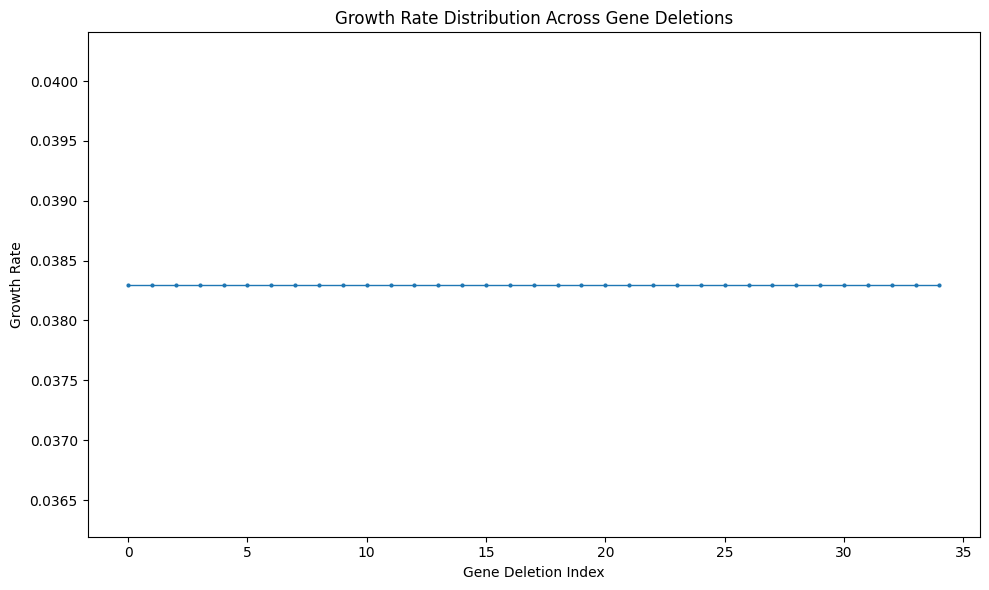

In [59]:
import matplotlib.pyplot as plt

growth_values = deletion_results['growth'].sort_values().reset_index(drop=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(growth_values.index, growth_values.values, marker='o', markersize=2, linewidth=1)

ax.set_xlabel('Gene Deletion Index')
ax.set_ylabel('Growth Rate')
ax.set_title('Growth Rate Distribution Across Gene Deletions')


plt.tight_layout()
plt.show()

# Double gene deletion

In [8]:
gene_lists = ['AAFOLC_17895', 'AAFOLC_17905', 'AAFOLC_17910', 'AAFOLC_17900','AAFOLC_05725',
              'AAFOLC_21105', 'AAFOLC_10685','AAFOLC_05285', 'AAFOLC_05270',
              'AAFOLC_05280', 'AAFOLC_05290', 'AAFOLC_05260', 'AAFOLC_05295',
                'AAFOLC_05265', 'AAFOLC_05275', 'AAFOLC_05300', 'AAFOLC_05305',
                'AAFOLC_02505', 'AAFOLC_02510', 'AAFOLC_02515']
deletion_results = double_gene_deletion(
    model,
    gene_list1=gene_lists,
    gene_list2=gene_lists,
    method="fba",      # optional; default is "fba"
)

In [56]:
deletion_results.growth=deletion_results.growth.round(4)
deletion_results

,ids,growth,status
0,{NAD_H2},0.0383,optimal
1,"{HYD3pp, FERHYD}",0.0383,optimal
2,{CYTHYD},0.0383,optimal
3,"{HYD2, NAD_H2}",0.0383,optimal
4,"{HYD3pp, HADPCOADH}",0.0383,optimal
5,"{HADPCOADH, CYTHYD}",0.0383,optimal
6,"{FERHYD, HYD2pp}",0.0383,optimal
7,"{HYD3pp, HYD2pp}",0.0383,optimal
8,"{HYD2, FERHYD}",0.0383,optimal
9,{HADPCOADH},0.0383,optimal


In [ ]:
deletion_results.to_csv(file_path/'250807_double_gene_deletion_hyd_gem.csv')

# Double reaction deletion

In [84]:
reactionlist= ['NAD_H2','FERHYD','HADPCOADH','CYTHYD','HYD1pp','HYD2pp','HYD3pp','HYD2']
deletion_results = double_reaction_deletion(model,reaction_list1 =reactionlist,reaction_list2 =reactionlist)
deletion_results

,ids,growth,status
0,{NAD_H2},0.030271,optimal
1,"{HYD3pp, FERHYD}",0.030271,optimal
2,{CYTHYD},0.030271,optimal
3,"{HYD2, NAD_H2}",0.030271,optimal
4,"{HYD3pp, HADPCOADH}",0.030271,optimal
5,"{HADPCOADH, CYTHYD}",0.030271,optimal
6,"{FERHYD, HYD2pp}",0.030271,optimal
7,"{HYD3pp, HYD2pp}",0.030271,optimal
8,"{HYD2, FERHYD}",0.030271,optimal
9,{HADPCOADH},0.030271,optimal


Bar plot gene deletion

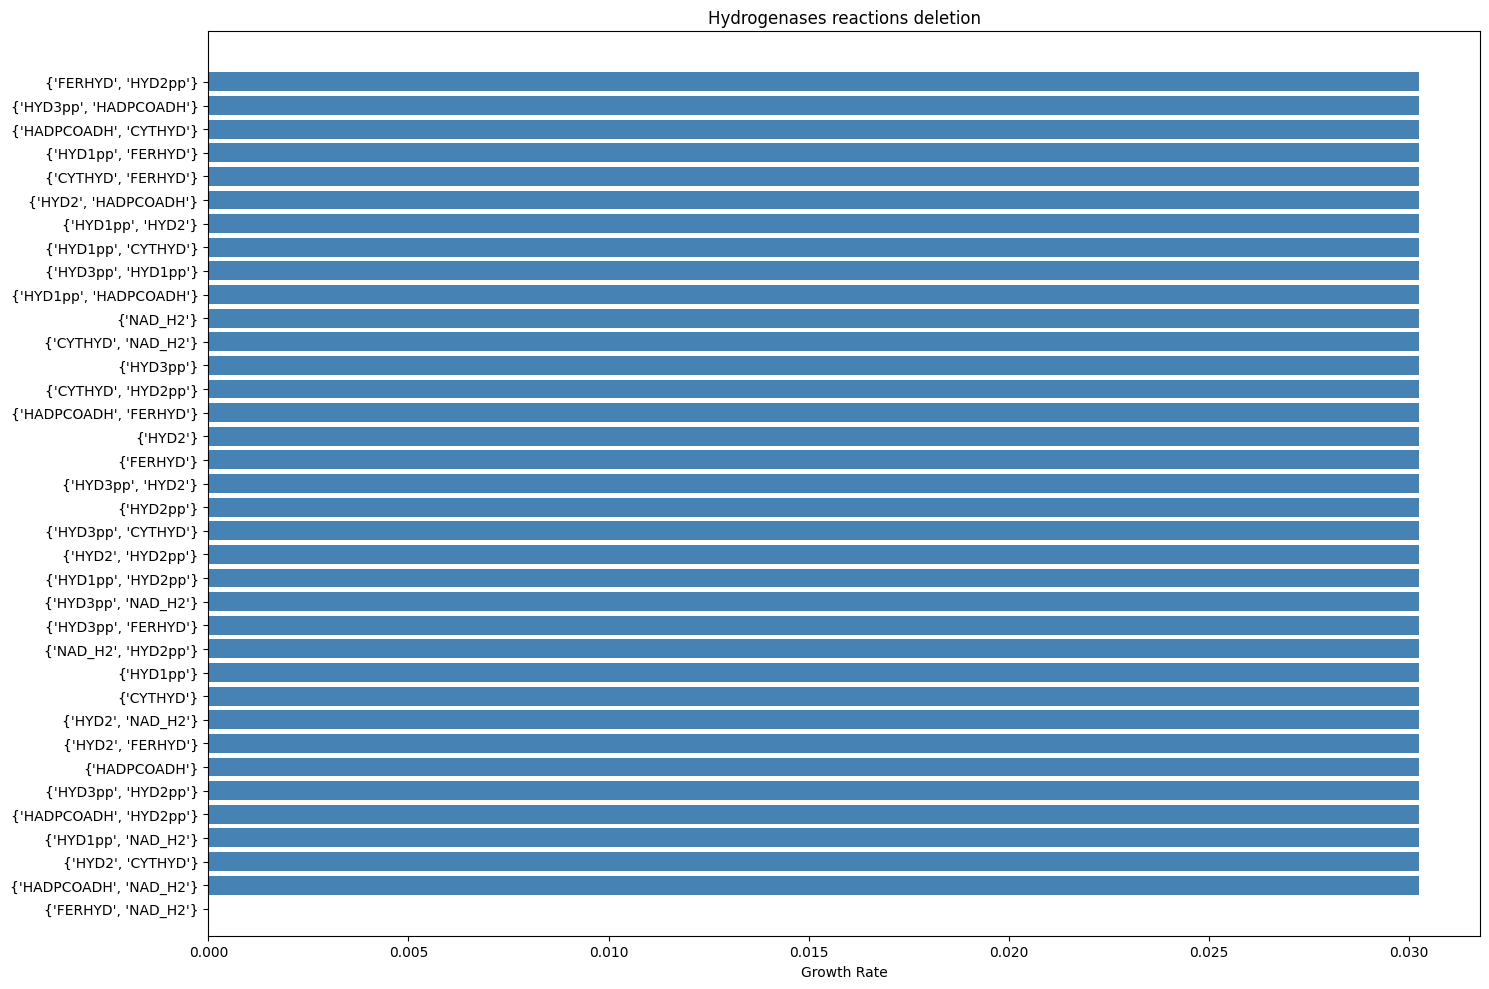

In [85]:
import matplotlib.pyplot as plt
# Plot the bar chart
# Ensure all labels are strings and fill missing ones
deletion_results['ids'] = deletion_results['ids'].fillna("unknown").astype(str)

# Optional: sort by lowest growth
deletion_results_sorted = deletion_results.sort_values(by='growth').head(70)

# Plot the bar chart
plt.figure(figsize=(15, 10))
plt.barh(deletion_results_sorted['ids'], deletion_results_sorted['growth'], color='steelblue')
plt.xlabel("Growth Rate")
plt.title("Hydrogenases reactions deletion")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Create a list of all reactions

In [ ]:
base_dir = Path.home() / "Documents" / "PhD" / "SoF1-GEM" / "Model" 
file_path = base_dir / "reaction_list.xlsx"
ju.export_reactions_to_excel(model, file_path)

# Create a list of all metabolites

In [ ]:
base_dir = Path.home() / "Documents" / "PhD" / "SoF1-GEM" / "Model" 
file_path = base_dir / "metabolites_list.xlsx"
ju.export_metabolites_to_excel(model, file_path)

# Create a list of all metabolites in a reaction

In [ ]:
reaction_id = 'Growth'
base_dir = Path.home() / "Documents" / "PhD" / "SoF1-GEM" / "Model" 
file_path = base_dir / f"metabolites_{reaction_id}_list.xlsx"
ju.export_metabolites_from_reaction(model, reaction_id, file_path)

# Calculate product yield

add a sink reaction for targeted product

In [ ]:
model.add_boundary(model.metabolites.get_by_id('hdca_c'), type='sink',lb=0.0, ub=1000)

change the substrat intake

In [ ]:
reaction = model.reactions.get_by_id('EX_glc__D_e')
reaction.bounds = -10.0, 0.0

calculate the yield (g/g)

In [ ]:
model.objective='SK_hdca_c'
model.optimize()


product_flux =  model.reactions.get_by_id('SK_hdca_c').flux
substrat_flux = - model.reactions.get_by_id('EX_glc__D_e').flux
product_MM = 280.45
substrat_MM = 180.156

yield_g_g = (product_flux * product_MM)/(substrat_flux*substrat_MM)
yield_g_g

# Model testing

## Preparing the dataset 

importing the gas consumptions

In [60]:
chemostat= pd.read_excel('../Data/240716_exp_gas_consumption.xlsx')
chemostat = chemostat.drop(chemostat.index[12:17],inplace=False) # remove outliers

add model predictions to the chemostat data

In [62]:
#addition of a growth rate column
chemostat['model_growth_rate'] = None
for index, row in chemostat.iterrows():
    with model as m_copy:
        
        # Set bounds for H2 flux
        h2_reaction = m_copy.reactions.get_by_id('EX_h2_e')
        h2_reaction.bounds = (-row['H2 Flux theoretic'], 0.0)

        # Set bounds for O2 flux
        o2_reaction = m_copy.reactions.get_by_id('EX_o2_e')
        o2_reaction.bounds = (-100.0, 0.0)

        # Set bounds for CO2 flux
        co2_reaction = m_copy.reactions.get_by_id('EX_co2_e')
        co2_reaction.bounds = (-100.0, 0.0)

        # Optimize the m_copy
        solution = m_copy.slim_optimize()
        print(solution)
        print(m_copy.reactions.get_by_id('EX_h2_e').flux)
        print(m_copy.reactions.get_by_id('EX_o2_e').flux)
        print(m_copy.reactions.get_by_id('EX_co2_e').flux)


        # Update the DataFrame with the solution and fluxes 
        chemostat.at[index, 'model_growth_rate'] = solution
        chemostat.at[index, 'H2_flux_model'] = m_copy.reactions.get_by_id('EX_h2_e').flux
        chemostat.at[index, 'O2_flux_model'] = m_copy.reactions.get_by_id('EX_o2_e').flux
        chemostat.at[index, 'CO2_flux_model'] = m_copy.reactions.get_by_id('EX_co2_e').flux

0.04458054983482768
-19.421127265861145
-7.4186412519714455
-2.1294400167011123
0.04317666445641467
-19.14334128889219
-7.351923154353286
-2.0623818553564193
0.04702037162974227
-19.9038933743707
-7.534591080345502
-2.24598084410148
0.03430388907734183
-17.38769042522724
-6.930254332249933
-1.6385637772619612
0.03474150091059358
-17.47428042217543
-6.9510513499114115
-1.659466797815926
0.033756939564025444
-17.27946584561073
-6.904261162449515
-1.6124381196583313
0.024419951448299976
-15.43196147983211
-6.460531144214263
-1.166446398991891
0.02519588850012225
-15.58549568947646
-6.497406693147769
-1.2035099034732775
0.02661934966533718
-15.86715511590536
-6.5650551083506885
-1.2715031242535688
0.024970420271847028
-15.54088242330096
-6.486691565335203
-1.1927401604000119
0.02220251933363635
-14.99319948700468
-6.3551501390677565
-1.0605282643618315
0.02540530798341899
-15.62693339989001
-6.507359122131478
-1.213513060223627


same code but the co2 was fixed

In [ ]:
#addition of a growth rate column
chemostat['model_growth_rate'] = None
for index, row in chemostat.iterrows():
    with model as m_copy:
        
        # Set bounds for H2 flux
        h2_reaction = m_copy.reactions.get_by_id('EX_h2_e')
        h2_reaction.bounds = (-100.0, 0.0)

        # Set bounds for O2 flux
        o2_reaction = m_copy.reactions.get_by_id('EX_o2_e')
        o2_reaction.bounds = (-100.0, 0.0)

        # Set bounds for CO2 flux
        co2_reaction = m_copy.reactions.get_by_id('EX_co2_e')
        co2_reaction.bounds = (-row['CO2 flux theoretic'], 0.0)

        # Optimize the m_copy
        solution = m_copy.slim_optimize()
        print(solution)
        print(m_copy.reactions.get_by_id('EX_h2_e').flux)
        print(m_copy.reactions.get_by_id('EX_o2_e').flux)
        print(m_copy.reactions.get_by_id('EX_co2_e').flux)


        # Update the DataFrame with the solution and fluxes 
        chemostat.at[index, 'model_growth_rate'] = solution
        chemostat.at[index, 'H2_flux_model'] = m_copy.reactions.get_by_id('EX_h2_e').flux
        chemostat.at[index, 'O2_flux_model'] = m_copy.reactions.get_by_id('EX_o2_e').flux
        chemostat.at[index, 'CO2_flux_model'] = m_copy.reactions.get_by_id('EX_co2_e').flux

In [63]:
chemostat.to_excel('../Data/251114_model_vs_exp_pred.xlsx')

## Plot exp vs sim (pretty colormetrie)

C:\Users\adam-1y9pxi6q95ggpmx\AppData\Local\Temp\ipykernel_13272\90071466.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("gnuplot2")


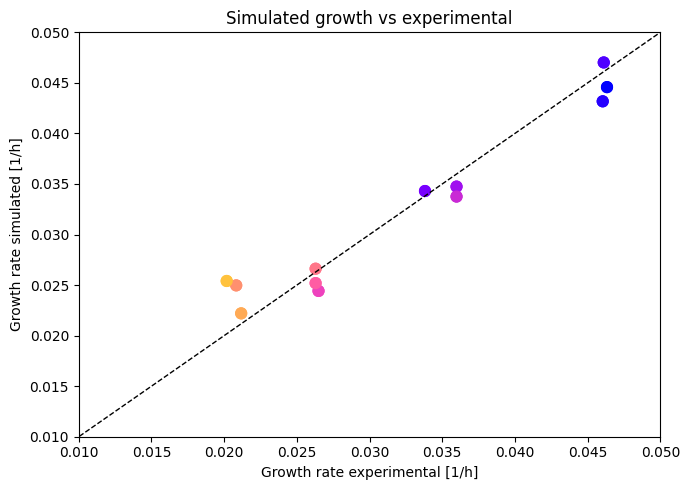

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

# Extract values
experimental = chemostat["exp_growth"].values
simulated = chemostat["model_growth_rate"].values

# Create color mapping for points
cmap = cm.get_cmap("gnuplot2")
colors = cmap(np.linspace(0.25, 0.8, len(chemostat)))
#colors = plt.cm.plasma(np.linspace(0, 1, len(df)))


# --- Plot ---
plt.figure(figsize=(7, 5))

# Scatter experimental vs simulated
plt.scatter(experimental, simulated, s=60, c=colors)
plt.scatter(experimental, simulated, s=60, c=colors)

# 1:1 diagonal line
min_val = min(0.0, 0.0)
max_val = max(0.05, 0.05)

plt.plot([min_val, max_val], [min_val, max_val], "k--", linewidth=1)

# Labels & formatting
plt.xlabel("Growth rate experimental [1/h]")
plt.ylabel("Growth rate simulated [1/h]")
plt.title("Simulated growth vs experimental", loc="center", fontsize=12)

plt.xlim(0.01, 0.05)
plt.ylim(0.01, 0.05)

plt.tight_layout()
plt.show()

## Production enveloppe

### Production envelope function (This function mainly works with H2 uptake)

In [7]:
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd

def cobra_flux_envelope(model, r_x, r_y, steps=20, constraints=None):
    """
    Compute envelope by scanning r_y (uptake) and computing min/max of r_x (growth).
    Returns:
        yvals (scan var), xmins (min growth), xmaxs (max growth)
    """
    m = model.copy()

    if constraints:
        for rxn_id, (lb, ub) in constraints.items():
            m.reactions.get_by_id(rxn_id).bounds = (lb, ub)

    rx = m.reactions.get_by_id(r_x)   # growth
    ry = m.reactions.get_by_id(r_y)   # uptake

    # sample the uptake (ry) range
    yvals = np.linspace(ry.lower_bound, ry.upper_bound, steps) # this needs to be modified in order to have proper production envelope

    xmins, xmaxs = [], []
    for y in yvals:
        with m:
            ry.bounds = (y, y)          # fix uptake to this value
            #print(y) debug 
            # maximize growth
            m.objective = rx
            sol_max = m.optimize()
            #print(sol_max) debug
            xmax = sol_max.fluxes[rx.id] if sol_max.status == "optimal" else np.nan

            # minimize growth
            m.objective_direction = "min"
            sol_min = m.optimize()
            xmin = sol_min.fluxes[rx.id] if sol_min.status == "optimal" else np.nan

        xmins.append(xmin)
        xmaxs.append(xmax)

    return np.array(yvals), np.array(xmins), np.array(xmaxs)


def plot_flux_envelope(
    model, r_x, r_y, steps=20, constraints=None,
    label_x=None, label_y=None, abs_y=True,
    plot_kwargs=None, fill_kwargs=None, ax=None
):
    """
    Plot envelope with Growth on X and uptake on Y.
    - r_x: reaction id for growth (plotted on X)
    - r_y: reaction id for uptake (plotted on Y)
    - abs_y: if True, plot uptake as positive (abs value)
    """
    offset = 0.03
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,5))
    else:
        fig = ax.figure

    if plot_kwargs is None:
        plot_kwargs = {"color": "k", "linewidth": 1.5}
    if fill_kwargs is None:
        fill_kwargs = {"color": plot_kwargs.get("color", "k"), "alpha": 0.15}

    # compute envelope (y = uptake sampled; x = growth ranges)
    yvals, xmins, xmaxs = cobra_flux_envelope(model, r_x, r_y, steps, constraints)

    # optionally convert uptake to positive numbers for plotting
    if abs_y:
        y_plot = np.abs(yvals)
    else:
        y_plot = yvals.copy()

    # PLOT: growth on X, uptake on Y
    ax.plot(xmins, y_plot, **plot_kwargs)   # min growth curve
    ax.plot(xmaxs, y_plot, **plot_kwargs)    # max growth curve

    # horizontal connectors at the two ends (draw line between xmin and xmax at first/last y)
    ax.plot([xmins[0], xmaxs[0]], [y_plot[0], y_plot[0]], **plot_kwargs)
    ax.plot([xmins[-1], xmaxs[-1]], [y_plot[-1], y_plot[-1]], **plot_kwargs)

    # fill between the two growth curves horizontally using fill_betweenx
    ax.fill_betweenx(y_plot, xmins, xmaxs, **fill_kwargs)

    # labels
    rx = model.reactions.get_by_id(r_x)
    ry = model.reactions.get_by_id(r_y)
    ax.set_xlabel(label_x if label_x else rx.name + " [1/h]")
    ax.set_ylabel(label_y if label_y else ry.name + " flux [mmol/gDW/h]")

    ax.invert_yaxis() if (not abs_y and np.nanmean(yvals) < 0) else None
    ax.margins(0)
    
    plt.xlim(0.0, 5.0)
    plt.ylim(0, 50.0) # needs to be adjusted manually
    fig.tight_layout()
    return ax

example of running function

c:\Users\adam-1y9pxi6q95ggpmx\AppData\Local\anaconda3\Lib\site-packages\cobra\util\solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


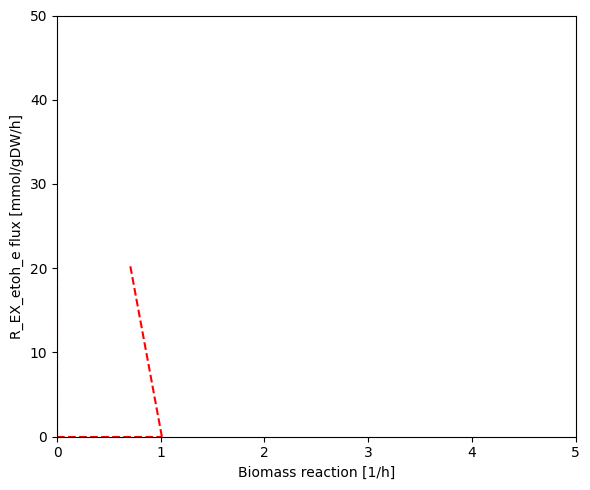

In [8]:
ax = plot_flux_envelope(
    model,
    r_x="Growth",         # growth on X
    r_y="EX_etoh_e",        # uptake on Y
    steps=50,
    #constraints={"EX_h2_e": (-50.0, -10.0)},
    abs_y=True,            # show uptake as positive numbers
    plot_kwargs={"color":"red", "linestyle":"--"},
    fill_kwargs={"alpha":0}
)


### Production envelope function 

Same function but with a different idea , where we fix growth and check the targeted reaction fluxes.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd

def flux_envelope_bis(model, biomass_rxn, target_rxn, steps, constraints=None):
    """
    Compute envelope by scanning target_rxn (uptake) and computing min/max of biomass_rxn (growth).
    Returns:
        yvals (scan var), xmins (min growth), xmaxs (max growth)
    """
    m = model.copy()

    if constraints:
        for rxn_id, (lb, ub) in constraints.items():
            m.reactions.get_by_id(rxn_id).bounds = (lb, ub)


    m.objective = biomass_rxn
    sol = m.optimize()
    # sample the uptake (ry) range
    xvals = np.linspace(0,sol.fluxes[biomass_rxn], steps) # this needs to be modified in order to have proper production envelope
    ymaxs , ymins  = [],[]

    for x in xvals:
        # print(f"Growth rate fixed = {x}")
        with m:
            m.reactions.get_by_id(biomass_rxn).lower_bound = x
            m.reactions.get_by_id(biomass_rxn).upper_bound = x  #fix the growth values
            #print(x) #debug 

            #***************************new code***************************

                        
            m.objective = target_rxn
            sol = m.optimize()
            # with model at fixed growth = x
            m.objective = target_rxn          # EX_h2_e
            m.objective_direction = "max"
            sol_max = m.optimize()
            target_flux_max = sol_max.fluxes[target_rxn]

            m.objective_direction = "min"
            sol_min = m.optimize()
            target_flux_min = sol_min.fluxes[target_rxn]
            # print(f"max flux: {target_flux_max}")
            # print(f"min flux: {target_flux_min}")
            ymins.append(target_flux_min)
            ymaxs.append(target_flux_max)
            #print(product_fluxes)

    return np.array(ymins), np.array(ymaxs), np.array(xvals)




def plot_flux_envelope_bis(
    model, biomass_rxn, target_rxn, steps=20, constraints=None,
    label_x=None, label_y=None, abs_y=True,
    plot_kwargs=None, fill_kwargs=None, ax=None
):
    """
    Plot envelope with Growth on X and product or uptake on Y.
    - biomass_rxn: reaction id for growth (plotted on X)
    - target_rxn: reaction id for uptake (plotted on Y)
    - abs_y: if True, plot uptake as positive (abs value)
    """

    if ax is None:
        fig, ax = plt.subplots(figsize=(6,5))
    else:
        fig = ax.figure

    if plot_kwargs is None:
        plot_kwargs = {"color": "k", "linewidth": 1.5}
    if fill_kwargs is None:
        fill_kwargs = {"color": plot_kwargs.get("color", "k"), "alpha": 0.4}

    # compute envelope (y = targeted reaction; x = growth ranges)
    ymins,ymaxs, xvals = flux_envelope_bis(model, biomass_rxn, target_rxn, steps, constraints)

    # optionally convert uptake to positive numbers for plotting
    if abs_y:
        ymins = np.abs(ymins)
        ymaxs = np.abs(ymaxs)

    # line
    ax.plot(xvals, ymins, **plot_kwargs)
    ax.plot(xvals, ymaxs, **plot_kwargs)
    
    # fill between the two growth curves horizontally using fill_between
    ax.fill_between(xvals,ymins,ymaxs, **fill_kwargs)

    # labels
    rx = model.reactions.get_by_id(biomass_rxn)
    ry = model.reactions.get_by_id(target_rxn)
    ax.set_xlabel(label_x if label_x else rx.name + " [1/h]")
    ax.set_ylabel(label_y if label_y else ry.name + " flux [mmol/gDW/h]")

    
        # custom tick spacing
    import matplotlib.ticker as ticker
    #ax.xaxis.set_major_locator(ticker.MultipleLocator(0.005))   # ticks every 0.005
    #ax.yaxis.set_major_locator(ticker.MultipleLocator(1.0))   # choose manual gap
    ax.margins(0)
    ax.set_xlim(0, max(xvals)*1.5)
    ax.set_ylim(0, ymins.max() * 1.5 if ymins.max()> ymaxs.max() else ymaxs.max() * 1.5 )
    fig.tight_layout()
    return ax

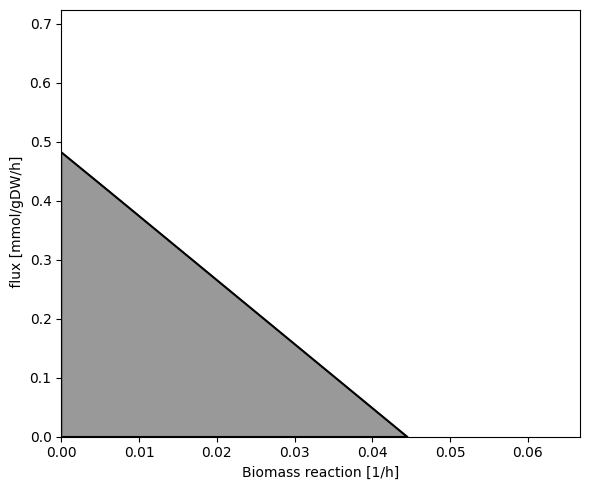

In [122]:
ax = plot_flux_envelope_bis(
    model,
    biomass_rxn="Growth",
    target_rxn="BLG_x1_production",
    steps=50,
    abs_y=True,
)
plt.show()


### Production envelopes for various datapoints.

C:\Users\adam-1y9pxi6q95ggpmx\AppData\Local\Temp\ipykernel_16252\383832265.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("gnuplot2")


19.14334128889219
19.9038933743707
17.38769042522724


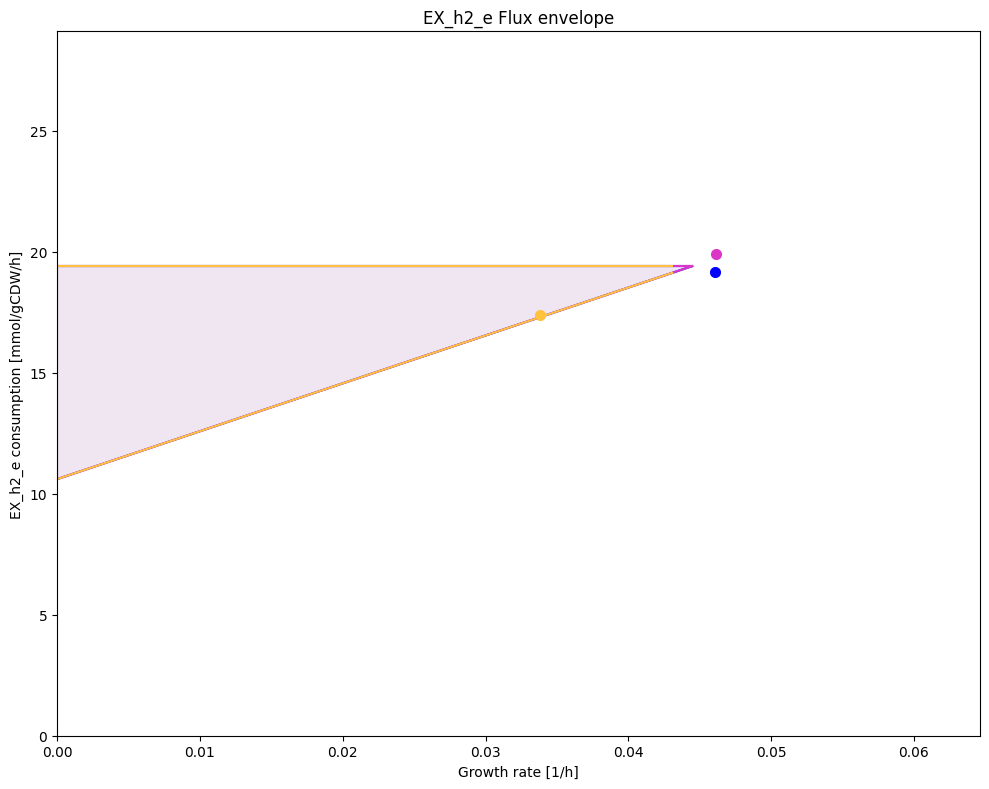

In [ ]:
#TODO co2 was fixed you can check the problem in the plotting
#TODO check the layer order you can use the last gpt discussion
# The scale of BLG production and H2 uptake is not the same and make plotting hard
test_df = chemostat_model.iloc[[1, 2, 3]]
q_co2 = test_df["CO2 flux theoretic"].values
q_h2 = test_df["H2 Flux theoretic"].values
mu = test_df["exp_growth"].values
def plot_flux_envelopes(model, data, objective = str):

    q_h2,q_co2, mu = data

    # --------------- 1) Compute simulated growth -----------------
    mu_sim = []
    constraints = {}

    for i in range(len(mu)):
        with model :
            #print(f'for itteration = {i} and H2 uptake of {q_h2[i]}')
            rxn = model.reactions.get_by_id("EX_co2_e")
            rxn.bounds = -q_co2[i], 0.0
            model.objective = objective
            sol = model.optimize()
            mu_pred = sol.objective_value 
            mu_sim.append(mu_pred)
            #print(f'Model simulated {mu_pred}')

    # --------------- 2) Prepare figure ---------------------------
    fig, ax = plt.subplots(figsize=(10,8))   # <--- FIXED
    cmap = cm.get_cmap("gnuplot2")
    colors = cmap(np.linspace(0.25, 0.8, len(q_h2)))
    rxn = "EX_h2_e"

    # --------------- 3) Flux envelopes ---------------------------
    model_copy = model.copy()

    for  q_h2_i,q_co2_i, mu_i, color_i in zip(q_h2,q_co2 ,mu, colors):

        # Fix growth
        rxn_obj = model_copy.reactions.get_by_id(objective)
        rxn_obj.lb = mu_i
        rxn_obj.ub = mu_i
        constraints_mu = {"EX_co2_e": (-q_co2_i, 0.0)}


#*************************new code*******************************
        # envelope unconstrained (solid)
        plot_flux_envelope_bis(
            model_copy,
            biomass_rxn="Growth",
            target_rxn="EX_h2_e",
            steps=50,
            constraints=constraints_mu,
            plot_kwargs={"color":color_i},
            fill_kwargs={"color":color_i, "alpha":0.05},
            ax=ax
        )

        print(q_h2_i)
        ax.plot(mu_i, q_h2_i, marker = 'o', color=color_i ,markersize=7,label=f"H2 uptake={q_h2_i}") # plot the experimental data points on the figure

    # Labels
    name = model.reactions.get_by_id(rxn).name

    ax.set_xlabel("Growth rate [1/h]")
    ax.set_ylabel(f"{name} consumption [mmol/gCDW/h]")
    ax.set_title(f"{name} Flux envelope")

    plt.tight_layout()
    plt.show()

plot_flux_envelopes(model, [q_h2,q_co2, mu],"Growth")



## PhPP Analysis

### 2D envelope

https://github.com/AlmaasLab/elixir-galaxy-tools-systemsbiology/blob/main/gem_tools/gem_phenotype_phase_plane.py  # check this

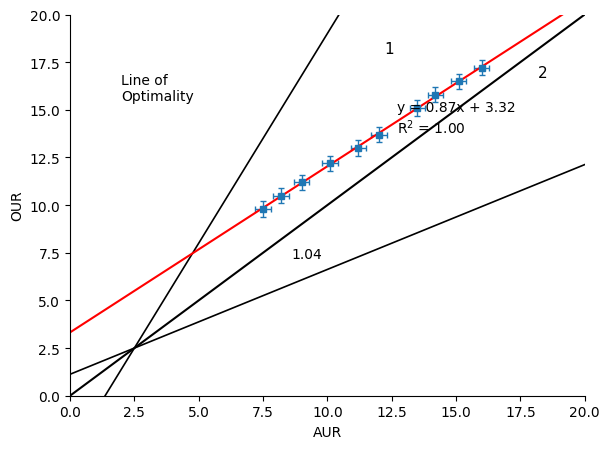

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# 1) Replace with YOUR data
# ----------------------------
x = np.array([7.5, 8.2, 9.0, 10.1, 11.2, 12.0, 13.5, 14.2, 15.1, 16.0])
y = np.array([9.8, 10.5, 11.2, 12.2, 13.0, 13.7, 15.1, 15.8, 16.5, 17.2])

# Optional error bars (set to None if you don't have them)
xerr = np.array([0.3]*len(x))
yerr = np.array([0.4]*len(y))

# ----------------------------
# 2) Linear regression + R^2
# ----------------------------
m, b = np.polyfit(x, y, 1)
y_hat = m*x + b
ss_res = np.sum((y - y_hat)**2)
ss_tot = np.sum((y - np.mean(y))**2)
r2 = 1 - ss_res/ss_tot

# ----------------------------
# 3) Plot limits
# ----------------------------
xmin, xmax = 0, 20
ymin, ymax = 0, 20

xx = np.linspace(xmin, xmax, 400)

# "Line of optimality" (often y=x)
y_opt = xx

# "Wedge" lines around optimality:
# Choose slopes to match your figure/definition
upper_slope = 2.2   # steeper boundary
lower_slope = 0.55  # flatter boundary

# If you want the wedge to start at a point other than (0,0), set (x0, y0)
x0, y0 = 2.5, 2.5
y_upper = y0 + upper_slope*(xx - x0)
y_lower = y0 + lower_slope*(xx - x0)

# Regression line
y_reg = m*xx + b

# ----------------------------
# 4) Draw
# ----------------------------
fig, ax = plt.subplots(figsize=(6.2, 4.6))

# Data (with error bars like in your figure)
if xerr is not None or yerr is not None:
    ax.errorbar(x, y, xerr=xerr, yerr=yerr, fmt='s', ms=4,
                capsize=2, elinewidth=1)
else:
    ax.plot(x, y, 's', ms=4)

# Line of optimality (black)
ax.plot(xx, y_opt, color='k', linewidth=1.5)

# Wedge boundary lines (black)
ax.plot(xx, y_upper, color='k', linewidth=1.2)
ax.plot(xx, y_lower, color='k', linewidth=1.2)

# Regression line (red)
ax.plot(xx, y_reg, color='red', linewidth=1.5)

# Labels, limits, ticks
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_xlabel("AUR")
ax.set_ylabel("OUR")

# ----------------------------
# 5) Text annotations (equation, R^2, labels)
# ----------------------------
eq_text = f"y = {m:.2f}x + {b:.2f}\nR$^2$ = {r2:.2f}"
ax.text(12.7, 13.8, eq_text, fontsize=10)

ax.text(2.0, 15.5, "Line of\nOptimality", fontsize=10)

# Example of putting "1" and "2" near regions (adjust positions)
ax.text(12.2, 18.0, "1", fontsize=11)
ax.text(18.2, 16.7, "2", fontsize=11)

# Example showing a ratio like "1.04" near the wedge (just a label)
ax.text(8.6, 7.2, "1.04", fontsize=10)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### 3D envelope with the build in function of cobrapy for the production envelope 

In [3]:
from cobra.flux_analysis.phenotype_phase_plane import production_envelope

results = production_envelope(
    model=model,
    reactions=["EX_h2_e", "EX_o2_e"],
    points=30,
    objective="Growth"
)


In [4]:
results.to_csv("../Results/PhPP/production_envelope_basemodel.csv")

In [17]:
# 2) Pivot into grids (this avoids the "saw-tooth" artifact)
piv_max = results.pivot(index="EX_o2_e", columns="EX_h2_e", values="flux_maximum")
piv_min = results.pivot(index="EX_o2_e", columns="EX_h2_e", values="flux_minimum")

X = piv_max.columns.values
Y = piv_max.index.values
Xg, Yg = np.meshgrid(X, Y)

Zmax = piv_max.values
Zmin = piv_min.values

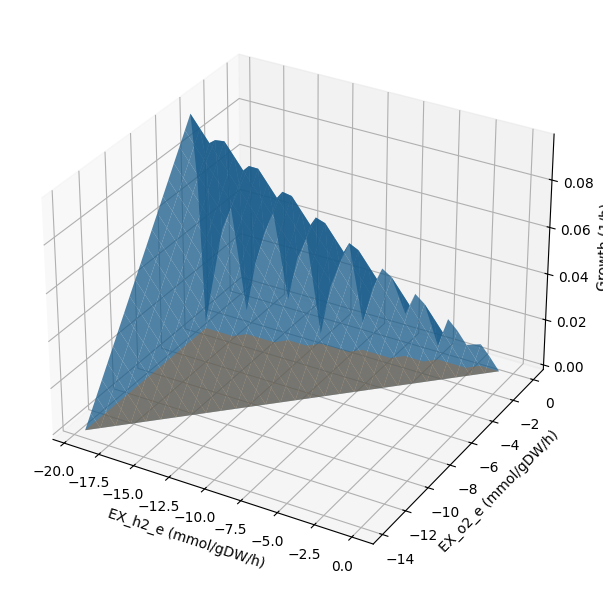

In [18]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

# Upper surface (max)
ax.plot_surface(Xg, Yg, Zmax, alpha=0.75, edgecolor="none")

# Lower surface (min)
ax.plot_surface(Xg, Yg, Zmin, alpha=0.35, edgecolor="none")

ax.set_xlabel("EX_h2_e (mmol/gDW/h)")
ax.set_ylabel("EX_o2_e (mmol/gDW/h)")
ax.set_zlabel("Growth (1/h)")

plt.tight_layout()
plt.show()

#### another style

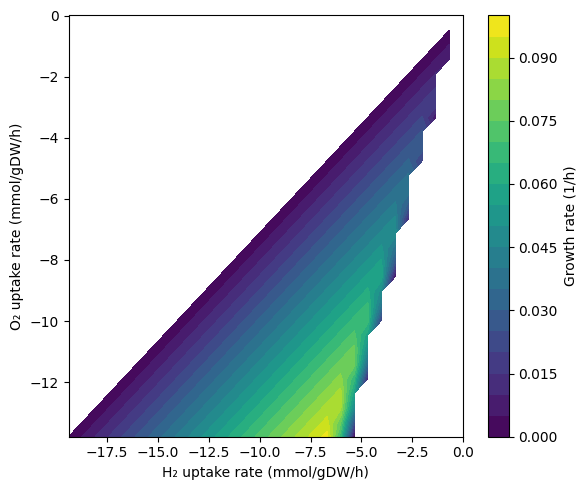

In [19]:
import numpy as np
import matplotlib.pyplot as plt

x = results["EX_h2_e"].values
y = results["EX_o2_e"].values
z = results["flux_maximum"].values

x_unique = np.unique(x)
y_unique = np.unique(y)

X, Y = np.meshgrid(x_unique, y_unique)
Z = z.reshape(len(y_unique), len(x_unique))

plt.figure(figsize=(6, 5))
contour = plt.contourf(X, Y, Z, levels=20, cmap="viridis")
plt.colorbar(contour, label="Growth rate (1/h)")

plt.xlabel("H₂ uptake rate (mmol/gDW/h)")
plt.ylabel("O₂ uptake rate (mmol/gDW/h)")
plt.tight_layout()
plt.show()

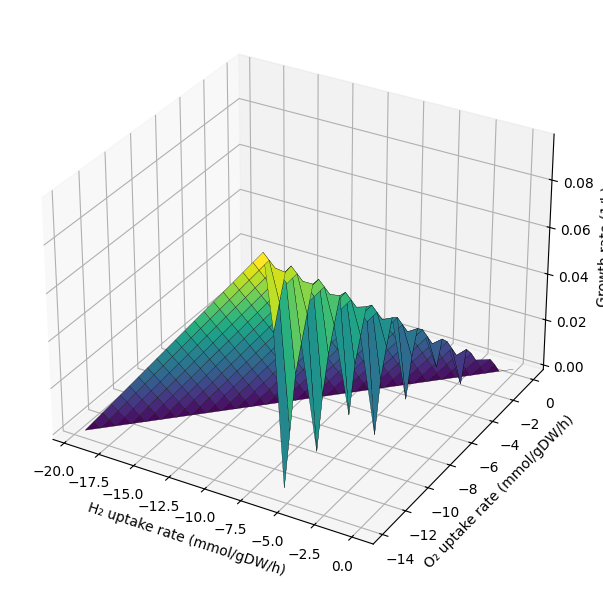

In [20]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(
    X, Y, Z,
    cmap="viridis",
    edgecolor="k",
    linewidth=0.2
)

ax.set_xlabel("H₂ uptake rate (mmol/gDW/h)")
ax.set_ylabel("O₂ uptake rate (mmol/gDW/h)")
ax.set_zlabel("Growth rate (1/h)")

plt.tight_layout()
plt.show()

### 2D envelope another style

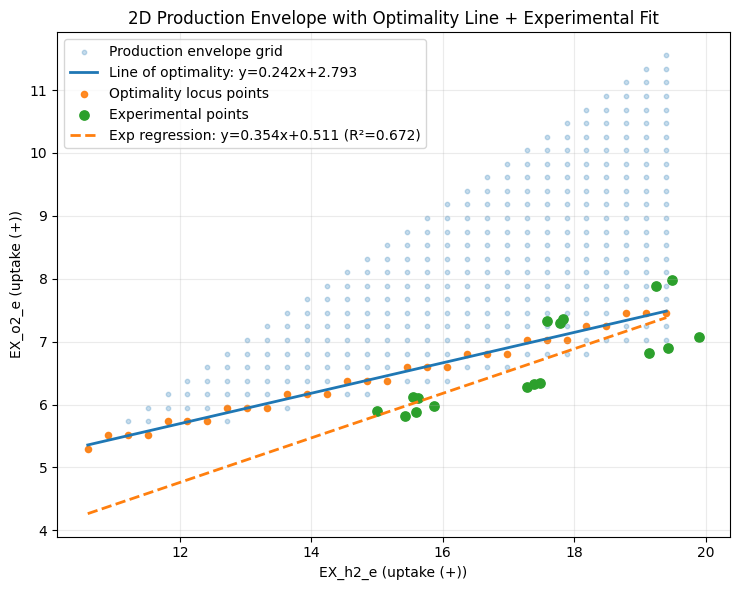

=== Summary ===
Optimality line: y = 0.241848 x + 2.793447
Experimental regression: y = 0.354183 x + 0.510675
R² (exp regression fit): 0.672305


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# ----------------------------
# 1) Load production envelope
# ----------------------------
envelope_path = "../Results/PhPP/production_envelope_basemodel.csv"  # <-- change if needed
df = pd.read_csv(envelope_path)

# Pick the 2 axes (these are the two varied reactions in your CSV)
x_col = "EX_h2_e"
y_col = "EX_o2_e"

# IMPORTANT: exchange reactions are often negative for uptake.
# If you want "uptake rates" as positive numbers on the plot, flip the sign here.
USE_POSITIVE_UPTAKE = True
if USE_POSITIVE_UPTAKE:
    df["x_plot"] = -df[x_col].astype(float)
    df["y_plot"] = -df[y_col].astype(float)
else:
    df["x_plot"] = df[x_col].astype(float)
    df["y_plot"] = df[y_col].astype(float)

# Objective columns produced by cobrapy.production_envelope
# flux_maximum is typically the maximum objective at that (x,y) grid point
obj_col = "flux_maximum"

# Keep only feasible points (some grids can have NaN)
df_feas = df.dropna(subset=["x_plot", "y_plot", obj_col]).copy()

# ----------------------------
# 2) Build "line of optimality"
# ----------------------------
# A common definition in a 2D envelope grid:
# For each x value, pick the y giving the maximum objective (flux_maximum).
# (You can also do it per y, depending on how you define optimality.)
df_feas["x_round"] = df_feas["x_plot"].round(10)  # stabilize grouping if float noise

opt_points = (
    df_feas.sort_values(obj_col, ascending=False)
           .groupby("x_round", as_index=False)
           .first()
           .sort_values("x_round")
)

x_opt = opt_points["x_plot"].to_numpy()
y_opt = opt_points["y_plot"].to_numpy()

# Fit a straight line to the optimality locus: y = m_opt*x + b_opt
opt_model = LinearRegression()
opt_model.fit(x_opt.reshape(-1, 1), y_opt)
m_opt = float(opt_model.coef_[0])
b_opt = float(opt_model.intercept_)


# ----------------------------
# 3) Load experimental points
# ----------------------------

# Put your file path here:
exp_path = '../Data/240716_exp_gas_consumption.xlsx'
exp = pd.read_excel(exp_path)

x_col_exp = "H2 Flux theoretic"
y_col_exp = "O2 flux theoretic"
if x_col_exp in exp.columns and y_col_exp in exp.columns:
    exp_x_raw = exp[x_col_exp].astype(float).to_numpy()
    exp_y_raw = exp[y_col_exp].astype(float).to_numpy()
else:
    raise ValueError(
        f"Experimental CSV must contain either ({x_col},{y_col}) or (x,y) columns."
    )



# ----------------------------
# 4) Linear regression on experimental points + R²
# ----------------------------
exp_model = LinearRegression()
exp_model.fit(exp_x_raw.reshape(-1, 1), exp_y_raw)
m_exp = float(exp_model.coef_[0])
b_exp = float(exp_model.intercept_)

y_exp_pred = exp_model.predict(exp_x_raw.reshape(-1, 1))
r2_exp_fit = r2_score(exp_y_raw, y_exp_pred)

# ----------------------------
# 5) R² of experimental points vs optimality line
# ----------------------------
y_opt_pred_at_exp = opt_model.predict(exp_y_raw.reshape(-1, 1))


# ----------------------------
# 6) Plot: envelope + optimality + exp points + exp regression
# ----------------------------
fig, ax = plt.subplots(figsize=(7.5, 6))

# Envelope "cloud" (grid points)
ax.scatter(
    df_feas["x_plot"], df_feas["y_plot"],
    s=10, alpha=0.25, label="Production envelope grid"
)

# Optimality line (from fitted optimal points)
x_line = np.linspace(df_feas["x_plot"].min(), df_feas["x_plot"].max(), 200)
y_line_opt = m_opt * x_line + b_opt
ax.plot(x_line, y_line_opt, linewidth=2, label=f"Line of optimality: y={m_opt:.3f}x+{b_opt:.3f}")

# Optional: show the actual optimal points used to fit the line
ax.scatter(x_opt, y_opt, s=20, alpha=0.9, label="Optimality locus points")

# Experimental points
ax.scatter(exp_x_raw, exp_y_raw, s=45, marker="o", label="Experimental points")

# Experimental regression line
y_line_exp = m_exp * x_line + b_exp
ax.plot(
    x_line, y_line_exp, linestyle="--", linewidth=2,
    label=f"Exp regression: y={m_exp:.3f}x+{b_exp:.3f} (R²={r2_exp_fit:.3f})"
)



ax.set_xlabel(f"{x_col} ({'uptake (+)' if USE_POSITIVE_UPTAKE else 'raw'})")
ax.set_ylabel(f"{y_col} ({'uptake (+)' if USE_POSITIVE_UPTAKE else 'raw'})")
ax.set_title("2D Production Envelope with Optimality Line + Experimental Fit")
ax.legend()
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

print("=== Summary ===")
print(f"Optimality line: y = {m_opt:.6f} x + {b_opt:.6f}")
print(f"Experimental regression: y = {m_exp:.6f} x + {b_exp:.6f}")
print(f"R² (exp regression fit): {r2_exp_fit:.6f}")



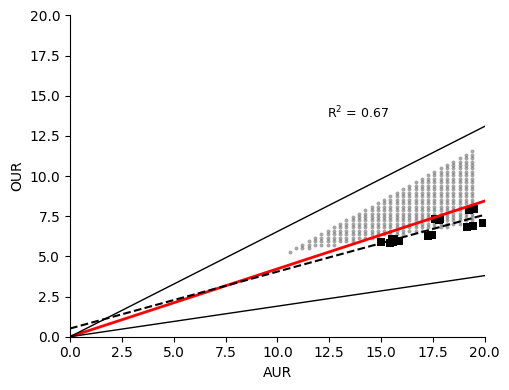

=== Summary ===
LO (through origin): y = 0.422538 x
Experimental regression: y = 0.354183 x + 0.510675
R² (exp regression): 0.672305


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# ----------------------------
# Settings to match the paper
# ----------------------------
envelope_path = "../Results/PhPP/production_envelope_basemodel.csv"
exp_path = "../Data/240716_exp_gas_consumption.xlsx"

# Axis reactions for envelope
x_col = "EX_h2_e"   # AUR equivalent
y_col = "EX_o2_e"   # OUR equivalent
obj_col = "flux_maximum"

# Experimental columns (your excel)
x_col_exp = "H2 Flux theoretic"
y_col_exp = "O2 flux theoretic"

# Make uptake positive (recommended for paper-like plot)
USE_POSITIVE_UPTAKE = True

# Plot limits like the figure
XMAX, YMAX = 20, 20

# ----------------------------
# 1) Load production envelope
# ----------------------------
df = pd.read_csv(envelope_path)

if USE_POSITIVE_UPTAKE:
    df["x_plot"] = -df[x_col].astype(float)
    df["y_plot"] = -df[y_col].astype(float)
else:
    df["x_plot"] = df[x_col].astype(float)
    df["y_plot"] = df[y_col].astype(float)

df_feas = df.dropna(subset=["x_plot", "y_plot", obj_col]).copy()

# ----------------------------
# 2) Build line of optimality (LO)
#    Ridge extraction + fit through origin (paper-style slope)
# ----------------------------
df_feas["x_round"] = df_feas["x_plot"].round(10)

opt_points = (
    df_feas.sort_values(obj_col, ascending=False)
           .groupby("x_round", as_index=False)
           .first()
           .sort_values("x_round")
)

x_opt = opt_points["x_plot"].to_numpy()
y_opt = opt_points["y_plot"].to_numpy()

# Fit LO through origin => slope only (like "1.04" in the paper)
opt_model = LinearRegression(fit_intercept=False)
opt_model.fit(x_opt.reshape(-1, 1), y_opt)
m_opt = float(opt_model.coef_[0])

# ----------------------------
# 3) Load experimental points
# ----------------------------
exp = pd.read_excel(exp_path)

exp_x_raw = exp[x_col_exp].astype(float).to_numpy()
exp_y_raw = exp[y_col_exp].astype(float).to_numpy()

# Apply same sign convention
if USE_POSITIVE_UPTAKE:
    exp_x = exp_x_raw
    exp_y = exp_y_raw
else:
    exp_x = exp_x_raw
    exp_y = exp_y_raw

# ----------------------------
# 4) Experimental regression (with intercept, like paper)
# ----------------------------
exp_model = LinearRegression(fit_intercept=True)
exp_model.fit(exp_x.reshape(-1, 1), exp_y)
m_exp = float(exp_model.coef_[0])
b_exp = float(exp_model.intercept_)

exp_y_pred = exp_model.predict(exp_x.reshape(-1, 1))
r2_exp = r2_score(exp_y, exp_y_pred)

# ----------------------------
# 5) Plot shaped like Fig 2A
# ----------------------------
fig, ax = plt.subplots(figsize=(5.2, 4.0))  # close to paper aspect

# Envelope grid points (black, small, semi-dense)
ax.scatter(df_feas["x_plot"], df_feas["y_plot"],
           s=8, c="black", alpha=0.35, linewidths=0)

# LO line (red, solid)
x_line = np.linspace(0, XMAX, 300)
y_lo = m_opt * x_line
ax.plot(x_line, y_lo, color="red", linewidth=2)

# Experimental regression (black, dashed)
y_exp_line = m_exp * x_line + b_exp
ax.plot(x_line, y_exp_line, color="black", linestyle="--", linewidth=1.5)

# Experimental points (black squares)
ax.scatter(exp_x, exp_y, s=28, c="black", marker="s", linewidths=0)

# Boundary rays to mimic the two black lines in the figure
# (These are visual guides; you can tune slopes if you want them exactly like your screenshot)
m_left = m_opt * 1.55   # steeper than LO
m_right = m_opt * 0.45  # shallower than LO
ax.plot(x_line, m_left * x_line, color="black", linewidth=1)
ax.plot(x_line, m_right * x_line, color="black", linewidth=1)

# Axis formatting (paper-like)
ax.set_xlim(0, XMAX)
ax.set_ylim(0, YMAX)
ax.set_xlabel("AUR")  # rename to match the paper
ax.set_ylabel("OUR")

# Remove top/right spines (classic paper style)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Text: regression equation & R2 (positioned like the figure)
eq_text = f"R$^2$ = {r2_exp:.2f}"
ax.text(12.4, 13.6, eq_text, fontsize=9)





ax.grid(False)
plt.tight_layout()
plt.show()

print("=== Summary ===")
print(f"LO (through origin): y = {m_opt:.6f} x")
print(f"Experimental regression: y = {m_exp:.6f} x + {b_exp:.6f}")
print(f"R² (exp regression): {r2_exp:.6f}")


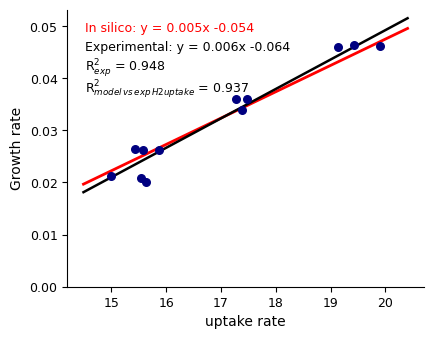

Experimental fit:
  y = 0.005646 x + -0.063691

In silico fit:
  y = 0.005054 x + -0.053571


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# ----------------------------
# Load data
# ----------------------------

df = pd.read_excel('../Data/251114_model_vs_exp_pred.xlsx')

# Experimental data
x_exp = pd.to_numeric(df["H2 Flux theoretic"], errors="coerce").to_numpy()
y_exp = pd.to_numeric(df["dilRate"], errors="coerce").to_numpy()

# In silico data
x_model = pd.to_numeric(- df["H2_flux_model"], errors="coerce").to_numpy()
y_model = pd.to_numeric(df["model_growth_rate"], errors="coerce").to_numpy()



# ----------------------------
# Experimental regression
# ----------------------------
exp_reg = LinearRegression()
exp_reg.fit(x_exp.reshape(-1, 1), y_exp)

m_exp = exp_reg.coef_[0]
b_exp = exp_reg.intercept_
r2_exp = r2_score(y_exp, exp_reg.predict(x_exp.reshape(-1, 1)))

# ----------------------------
# In silico regression (LO projection)
# ----------------------------
model_reg = LinearRegression()
model_reg.fit(x_model.reshape(-1, 1), y_model)

m_model = model_reg.coef_[0]
b_model = model_reg.intercept_

r2_model_vs_exp = r2_score(y_exp, y_model)

# ----------------------------
# Plot (Fig. 3A style)
# ----------------------------
fig, ax = plt.subplots(figsize=(4.6, 3.6))

# Experimental points
ax.scatter(
    x_exp, y_exp,
    color="navy", s=30, zorder=3
)
yield_flux = y_model/ x_model
ax.scatter(
    x_exp, y_exp,
    color="navy", s=30, zorder=3
)

# Lines
x_line = np.linspace(
    min(x_exp.min(), x_model.min()) - 0.5,
    max(x_exp.max(), x_model.max()) + 0.5,
    300
)

ax.plot(
    x_line, m_model * x_line + b_model,
    color="red", linewidth=2
)

ax.plot(
    x_line, m_exp * x_line + b_exp,
    color="black", linewidth=1.8
)

# ----------------------------
# Annotations (paper-style)
# ----------------------------

# In silico line equation (red)
ax.text(
    0.05, 0.92,
    f"In silico: y = {m_model:.3f}x {b_model:+.3f}",
    color="red", fontsize=9,
    transform=ax.transAxes
)

# Experimental regression + R²
ax.text(
    0.05, 0.78,
    f"Experimental: y = {m_exp:.3f}x {b_exp:+.3f}\n"
    f"R$^2_{{exp}}$ = {r2_exp:.3f}",
    color="black", fontsize=9,
    transform=ax.transAxes
)

# R² between model and experiment
ax.text(
    0.05, 0.70,
    f"R$^2_{{model\\,vs\\,exp\\,H2 uptake}}$ = {r2_model_vs_exp:.3f}",
    color="black", fontsize=9,
    transform=ax.transAxes
)
# ----------------------------
# Axis styling
# ----------------------------
ax.set_xlabel("uptake rate", fontsize=10)
ax.set_ylabel("Growth rate", fontsize=10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(labelsize=9)

ax.grid(False)
ax.set_ylim(bottom=0)

plt.show()

# ----------------------------
# Console summary
# ----------------------------
print("Experimental fit:")
print(f"  y = {m_exp:.6f} x + {b_exp:.6f}")

print("\nIn silico fit:")
print(f"  y = {m_model:.6f} x + {b_model:.6f}")


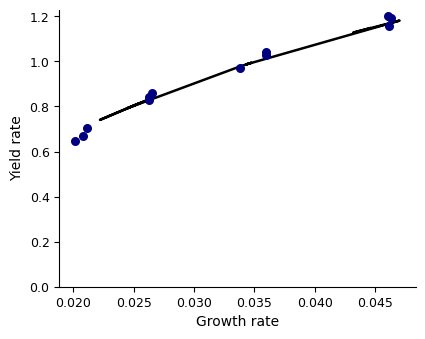

Experimental fit:
  y = 0.005646 x + -0.063691

In silico fit:
  y = 0.005054 x + -0.053571


In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# ----------------------------
# Load data
# ----------------------------

df = pd.read_excel('../Data/251114_model_vs_exp_pred.xlsx')

# Experimental data
x_exp = pd.to_numeric(df["H2 Flux theoretic"], errors="coerce").to_numpy()
y_exp = pd.to_numeric(df["dilRate"], errors="coerce").to_numpy()

# In silico data
x_model = pd.to_numeric(- df["H2_flux_model"], errors="coerce").to_numpy()
y_model = pd.to_numeric(df["model_growth_rate"], errors="coerce").to_numpy()



# ----------------------------
# Experimental regression
# ----------------------------
exp_reg = LinearRegression()
exp_reg.fit(x_exp.reshape(-1, 1), y_exp)

m_exp = exp_reg.coef_[0]
b_exp = exp_reg.intercept_
r2_exp = r2_score(y_exp, exp_reg.predict(x_exp.reshape(-1, 1)))

# ----------------------------
# In silico regression (LO projection)
# ----------------------------
model_reg = LinearRegression()
model_reg.fit(x_model.reshape(-1, 1), y_model)

m_model = model_reg.coef_[0]
b_model = model_reg.intercept_

r2_model_vs_exp = r2_score(y_exp, y_model)

# ----------------------------
# Plot (Fig. 3A style)
# ----------------------------
fig, ax = plt.subplots(figsize=(4.6, 3.6))

yield_exp = (y_exp/ x_exp)/0.002
yield_model = (y_model/ x_model)/0.002
ax.scatter(
    y_exp, yield_exp,
    color="navy", s=30, zorder=3
)




ax.plot(
    y_model,yield_model,
    color="black", linewidth=1.8
)


# ----------------------------
# Axis styling
# ----------------------------
ax.set_xlabel("Growth rate", fontsize=10)
ax.set_ylabel("Yield rate", fontsize=10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(labelsize=9)

ax.grid(False)
ax.set_ylim(bottom=0)

plt.show()

# ----------------------------
# Console summary
# ----------------------------
print("Experimental fit:")
print(f"  y = {m_exp:.6f} x + {b_exp:.6f}")

print("\nIn silico fit:")
print(f"  y = {m_model:.6f} x + {b_model:.6f}")
